In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np

# Bar plot

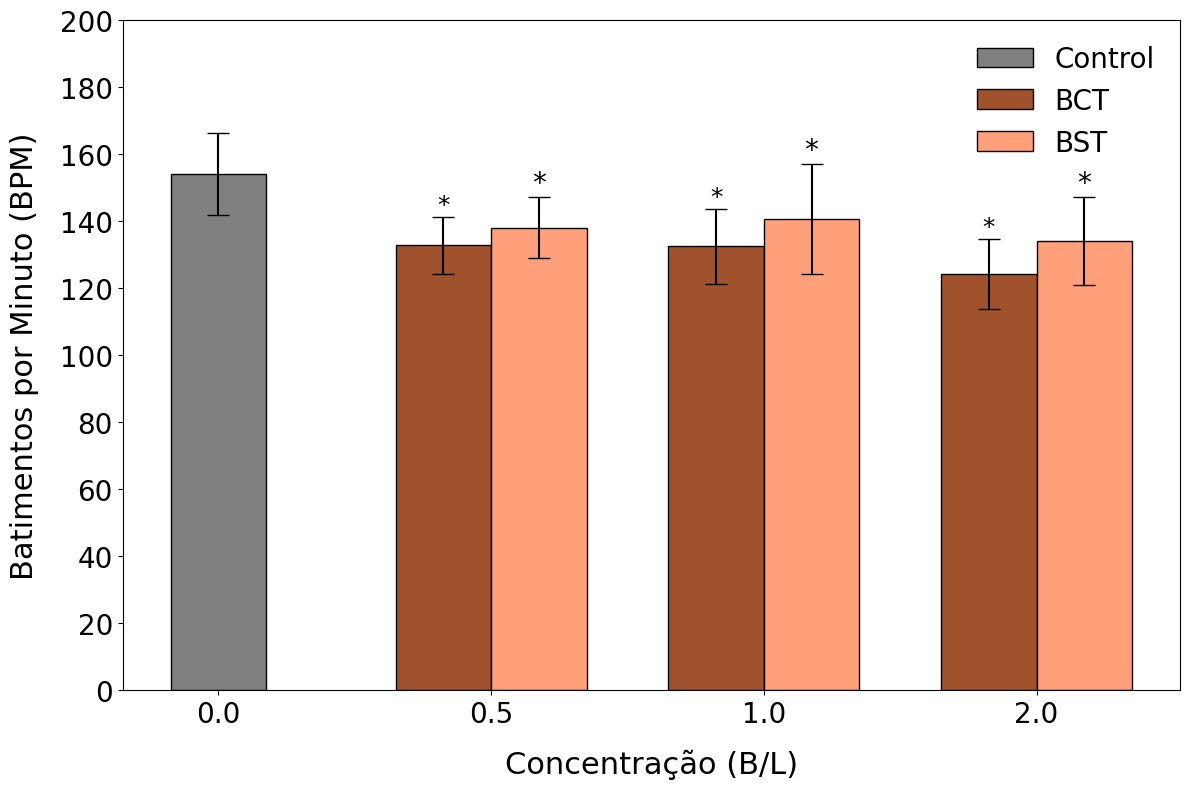

In [346]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_excel('../Ensaios Zebrafish/premium/dataset_zebrafish.xlsx')

# Agrupar por type e concentration
df_plot = (
    df.groupby(['type', 'concentration'])['bpm']
      .agg(['mean', 'std'])
      .reset_index()
)

# Definir cores fixas
colors = {
    'control': 'gray',
    'BCT': 'sienna',
    'BST': 'lightsalmon'
}

# Separar controle dos tratamentos
control_data = df_plot[df_plot['type'].str.lower() == 'control']
treatments_data = df_plot[df_plot['type'].str.lower() != 'control']

# Pegar concentrações únicas (excluindo o controle)
concentrations = sorted(treatments_data['concentration'].unique())

# Definir largura e deslocamento das barras
bar_width = 0.35
x = np.arange(len(concentrations)) + 1  # começar do 1, porque 0 é o controle

fig, ax = plt.subplots(figsize=(12, 8))

# Plot controle no x=0
if not control_data.empty:
    c_mean = control_data['mean'].values[0]
    c_std = control_data['std'].values[0]
    ax.bar(
        0.0, c_mean, yerr=c_std, capsize=8,
        color=colors['control'], edgecolor='black',
        width=bar_width, label='Control'
    )

# Plotar tratamentos lado a lado
for i, conc in enumerate(concentrations, start=1):
    # BCT
    bct_row = treatments_data[(treatments_data['type'] == 'BCT') & (treatments_data['concentration'] == conc)]
    if not bct_row.empty:
        ax.bar(
            i - bar_width/2, bct_row['mean'].values[0], 
            yerr=bct_row['std'].values[0], capsize=8,
            color=colors['BCT'], edgecolor='black',
            width=bar_width, label='BCT'
        )

    # BST
    bst_row = treatments_data[(treatments_data['type'] == 'BST') & (treatments_data['concentration'] == conc)]
    if not bst_row.empty:
        ax.bar(
            i + bar_width/2, bst_row['mean'].values[0], 
            yerr=bst_row['std'].values[0], capsize=8,
            color=colors['BST'], edgecolor='black',
            width=bar_width, label='BST'
        )

# Rótulos e eixos
ax.set_xlabel('Concentração (B/L)', fontsize=22,labelpad=15)
ax.set_ylabel('Batimentos por Minuto (BPM)', fontsize=22, labelpad=15)

y_offset = 0  # deslocamento acima da barra
col = 'k'

# Controle (não precisa marcar, mas se quiser pode deixar em branco ou marcar também)
x_control = 0.0  

# Loop em todas as barras de tratamentos
for i, conc in enumerate(concentrations, start=1):
    # BCT
    bct_row = treatments_data[(treatments_data['type'] == 'BCT') & (treatments_data['concentration'] == conc)]
    if not bct_row.empty:
        x_bct = i - bar_width/2
        y_bct = bct_row['mean'].values[0] + bct_row['std'].values[0]
        ax.text(x_bct, y_bct + y_offset, "*", ha='center', va='bottom',
                color=col, fontsize=18)

    # BST
    bst_row = treatments_data[(treatments_data['type'] == 'BST') & (treatments_data['concentration'] == conc)]
    if not bst_row.empty:
        x_bst = i + bar_width/2
        y_bst = bst_row['mean'].values[0] + bst_row['std'].values[0]
        ax.text(x_bst, y_bst + y_offset, "*", ha='center', va='bottom',
                color=col, fontsize=20)
        
# Colocar ticks no eixo X
ax.set_xticks([0.0] + list(np.arange(1, len(concentrations)+1)))
ax.set_xticklabels(['0.0'] + [str(c) for c in concentrations], fontsize=20)
ax.set_yticks(np.arange(0,210,20))
ax.tick_params(axis='y', labelsize=20)

# Remover duplicatas da legenda
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
leg = ax.legend(by_label.values(), by_label.keys(), fontsize=20)
leg.get_frame().set_facecolor('none')   # fundo transparente
leg.get_frame().set_edgecolor('none')   # sem borda

plt.tight_layout()
plt.show()

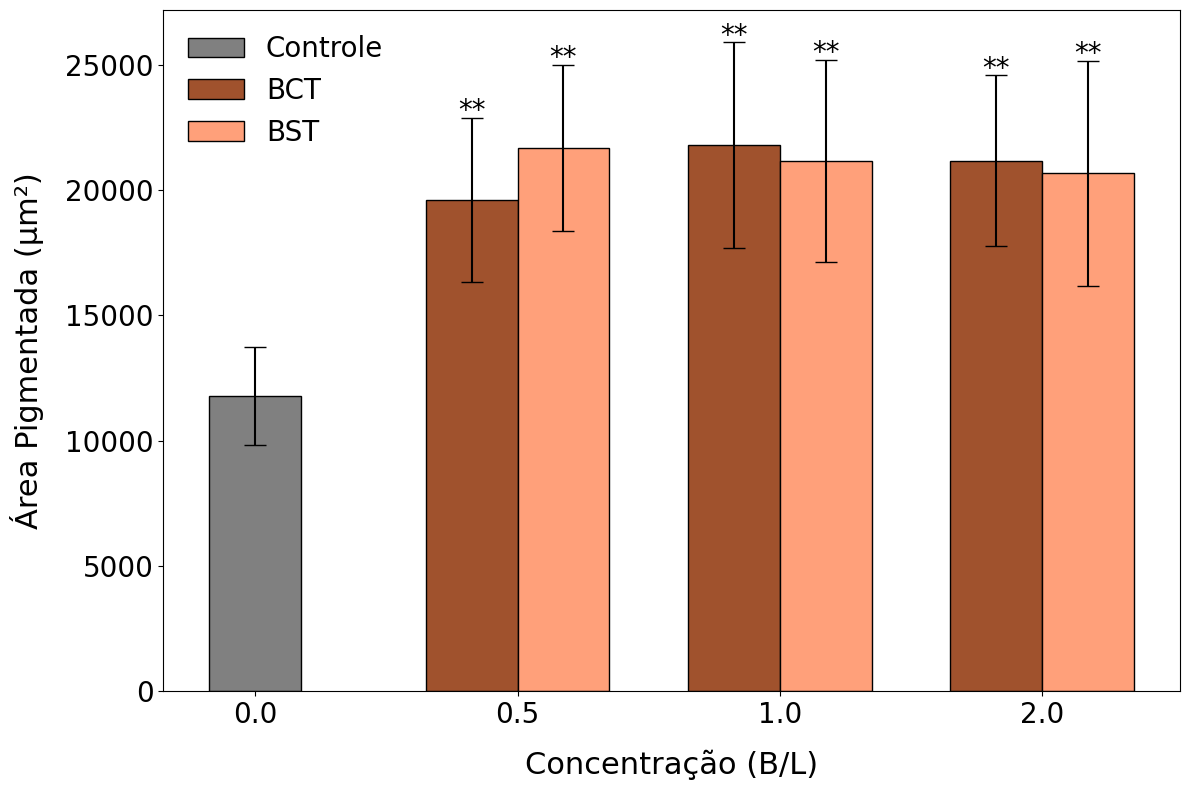

In [349]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Agrupar por type e concentration
df_plot = (
    df.groupby(['type', 'concentration'])['pigmented_area']
      .agg(['mean', 'std'])
      .reset_index()
)

# Definir cores fixas
colors = {
    'control': 'gray',
    'BCT': 'sienna',
    'BST': 'lightsalmon'
}

# Separar controle dos tratamentos
control_data = df_plot[df_plot['type'].str.lower() == 'control']
treatments_data = df_plot[df_plot['type'].str.lower() != 'control']

# Pegar concentrações únicas (excluindo o controle)
concentrations = sorted(treatments_data['concentration'].unique())

# Definir largura e deslocamento das barras
bar_width = 0.35
x = np.arange(len(concentrations)) + 1  # começar do 1, porque 0 é o controle

fig, ax = plt.subplots(figsize=(12, 8))

# Plot controle no x=0
if not control_data.empty:
    c_mean = control_data['mean'].values[0]
    c_std = control_data['std'].values[0]
    ax.bar(
        0.0, c_mean, yerr=c_std, capsize=8,
        color=colors['control'], edgecolor='black',
        width=bar_width, label='Controle'
    )

# Plotar tratamentos lado a lado
for i, conc in enumerate(concentrations, start=1):
    # BCT
    bct_row = treatments_data[(treatments_data['type'] == 'BCT') & (treatments_data['concentration'] == conc)]
    if not bct_row.empty:
        ax.bar(
            i - bar_width/2, bct_row['mean'].values[0], 
            yerr=bct_row['std'].values[0], capsize=8,
            color=colors['BCT'], edgecolor='black',
            width=bar_width, label='BCT'
        )

    # BST
    bst_row = treatments_data[(treatments_data['type'] == 'BST') & (treatments_data['concentration'] == conc)]
    if not bst_row.empty:
        ax.bar(
            i + bar_width/2, bst_row['mean'].values[0], 
            yerr=bst_row['std'].values[0], capsize=8,
            color=colors['BST'], edgecolor='black',
            width=bar_width, label='BST'
        )

# Rótulos e eixos
ax.set_xlabel('Concentração (B/L)', fontsize=22, labelpad=15)
ax.set_ylabel('Área Pigmentada (μm²)', fontsize=22, labelpad=15)

# Adicionar asteriscos acima das barras
y_offset = 0  # ajuste fino se quiser espaço maior
col = 'k'

# Loop em todas as barras de tratamentos
for i, conc in enumerate(concentrations, start=1):
    # BCT
    bct_row = treatments_data[(treatments_data['type'] == 'BCT') & (treatments_data['concentration'] == conc)]
    if not bct_row.empty:
        x_bct = i - bar_width/2
        y_bct = bct_row['mean'].values[0] + bct_row['std'].values[0]
        ax.text(x_bct, y_bct + y_offset - 300, "**", ha='center', va='bottom',
                color=col, fontsize=20)

    # BST
    bst_row = treatments_data[(treatments_data['type'] == 'BST') & (treatments_data['concentration'] == conc)]
    if not bst_row.empty:
        x_bst = i + bar_width/2
        y_bst = bst_row['mean'].values[0] + bst_row['std'].values[0]
        ax.text(x_bst, y_bst + y_offset - 300, "**", ha='center', va='bottom',
                color=col, fontsize=20)

# Colocar ticks no eixo X
ax.set_xticks([0.0] + list(np.arange(1, len(concentrations)+1)))
ax.set_xticklabels(['0.0'] + [str(c) for c in concentrations], fontsize=20)

ax.tick_params(axis='y', labelsize=20)

# Remover duplicatas da legenda
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
leg = ax.legend(by_label.values(), by_label.keys(), fontsize=20)
leg.get_frame().set_facecolor('none')   # fundo transparente
leg.get_frame().set_edgecolor('none')   # sem borda

plt.tight_layout()
plt.show()


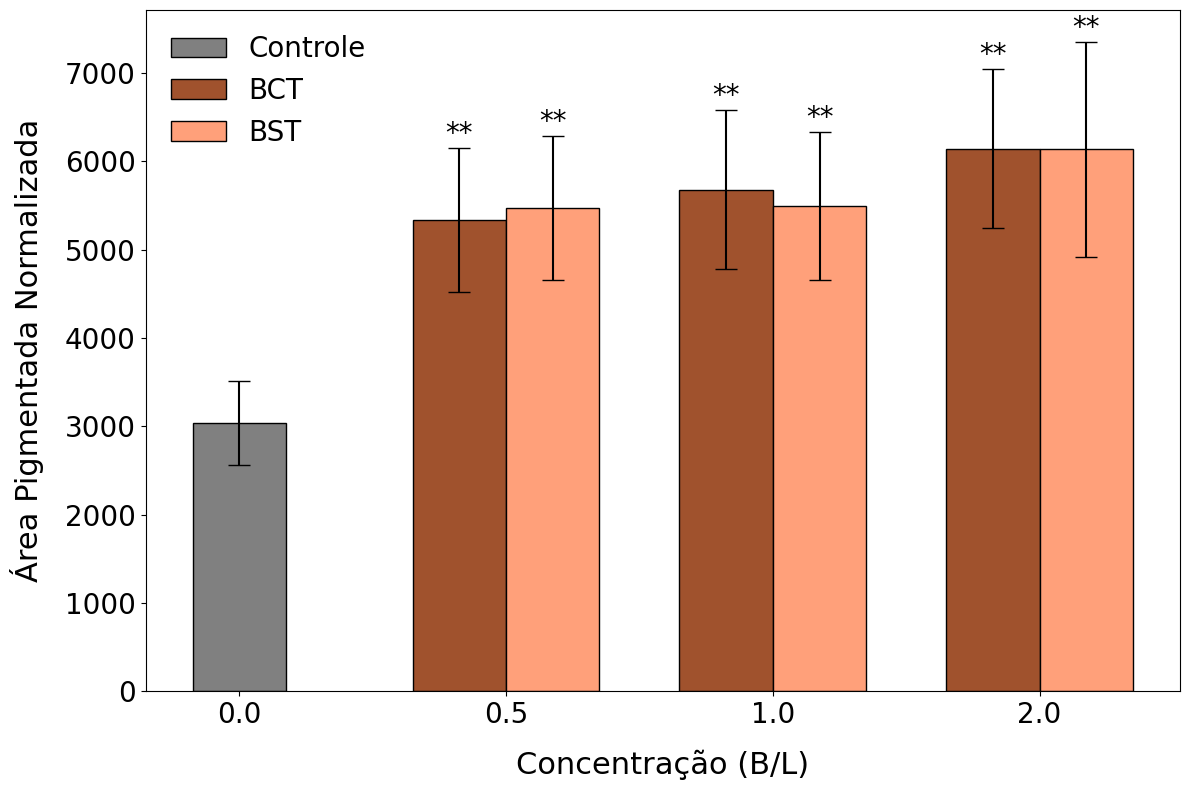

In [352]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Criar coluna normalizada
df['pigmented_norm'] = df['pigmented_area'] / df['body_length']

# Agrupar por type e concentration usando a variável normalizada
df_plot = (
    df.groupby(['type', 'concentration'])['pigmented_norm']
      .agg(['mean', 'std'])
      .reset_index()
)

# Definir cores fixas
colors = {
    'control': 'gray',
    'BCT': 'sienna',
    'BST': 'lightsalmon'
}

# Separar controle dos tratamentos
control_data = df_plot[df_plot['type'].str.lower() == 'control']
treatments_data = df_plot[df_plot['type'].str.lower() != 'control']

# Pegar concentrações únicas (excluindo o controle)
concentrations = sorted(treatments_data['concentration'].unique())

# Definir largura e deslocamento das barras
bar_width = 0.35
x = np.arange(len(concentrations)) + 1  # começar do 1, porque 0 é o controle

fig, ax = plt.subplots(figsize=(12, 8))

# Plot controle no x=0
if not control_data.empty:
    c_mean = control_data['mean'].values[0]
    c_std = control_data['std'].values[0]
    ax.bar(
        0.0, c_mean, yerr=c_std, capsize=8,
        color=colors['control'], edgecolor='black',
        width=bar_width, label='Controle'
    )

# Plotar tratamentos lado a lado
for i, conc in enumerate(concentrations, start=1):

    # BCT
    bct_row = treatments_data[(treatments_data['type'] == 'BCT') & (treatments_data['concentration'] == conc)]
    if not bct_row.empty:
        ax.bar(
            i - bar_width/2, bct_row['mean'].values[0], 
            yerr=bct_row['std'].values[0], capsize=8,
            color=colors['BCT'], edgecolor='black',
            width=bar_width, label='BCT'
        )

    # BST
    bst_row = treatments_data[(treatments_data['type'] == 'BST') & (treatments_data['concentration'] == conc)]
    if not bst_row.empty:
        ax.bar(
            i + bar_width/2, bst_row['mean'].values[0], 
            yerr=bst_row['std'].values[0], capsize=8,
            color=colors['BST'], edgecolor='black',
            width=bar_width, label='BST'
        )

# Rótulos e eixos
ax.set_xlabel('Concentração (B/L)', fontsize=22, labelpad=15)
ax.set_ylabel('Área Pigmentada Normalizada', fontsize=22, labelpad=15)

# Adicionar asteriscos
y_offset = 0
col = 'k'

for i, conc in enumerate(concentrations, start=1):

    # BCT
    bct_row = treatments_data[(treatments_data['type'] == 'BCT') & (treatments_data['concentration'] == conc)]
    if not bct_row.empty:
        x_bct = i - bar_width/2
        y_bct = bct_row['mean'].values[0] + bct_row['std'].values[0]
        ax.text(x_bct, y_bct + y_offset, "**", ha='center', va='bottom',
                color=col, fontsize=20)

    # BST
    bst_row = treatments_data[(treatments_data['type'] == 'BST') & (treatments_data['concentration'] == conc)]
    if not bst_row.empty:
        x_bst = i + bar_width/2
        y_bst = bst_row['mean'].values[0] + bst_row['std'].values[0]
        ax.text(x_bst, y_bst + y_offset, "**", ha='center', va='bottom',
                color=col, fontsize=20)

# Colocar ticks no eixo X
ax.set_xticks([0.0] + list(np.arange(1, len(concentrations) + 1)))
ax.set_xticklabels(['0.0'] + [str(c) for c in concentrations], fontsize=20)

ax.tick_params(axis='y', labelsize=20)

# Remover duplicatas da legenda
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
leg = ax.legend(by_label.values(), by_label.keys(), fontsize=20)
leg.get_frame().set_facecolor('none')
leg.get_frame().set_edgecolor('none')

plt.tight_layout()
plt.show()


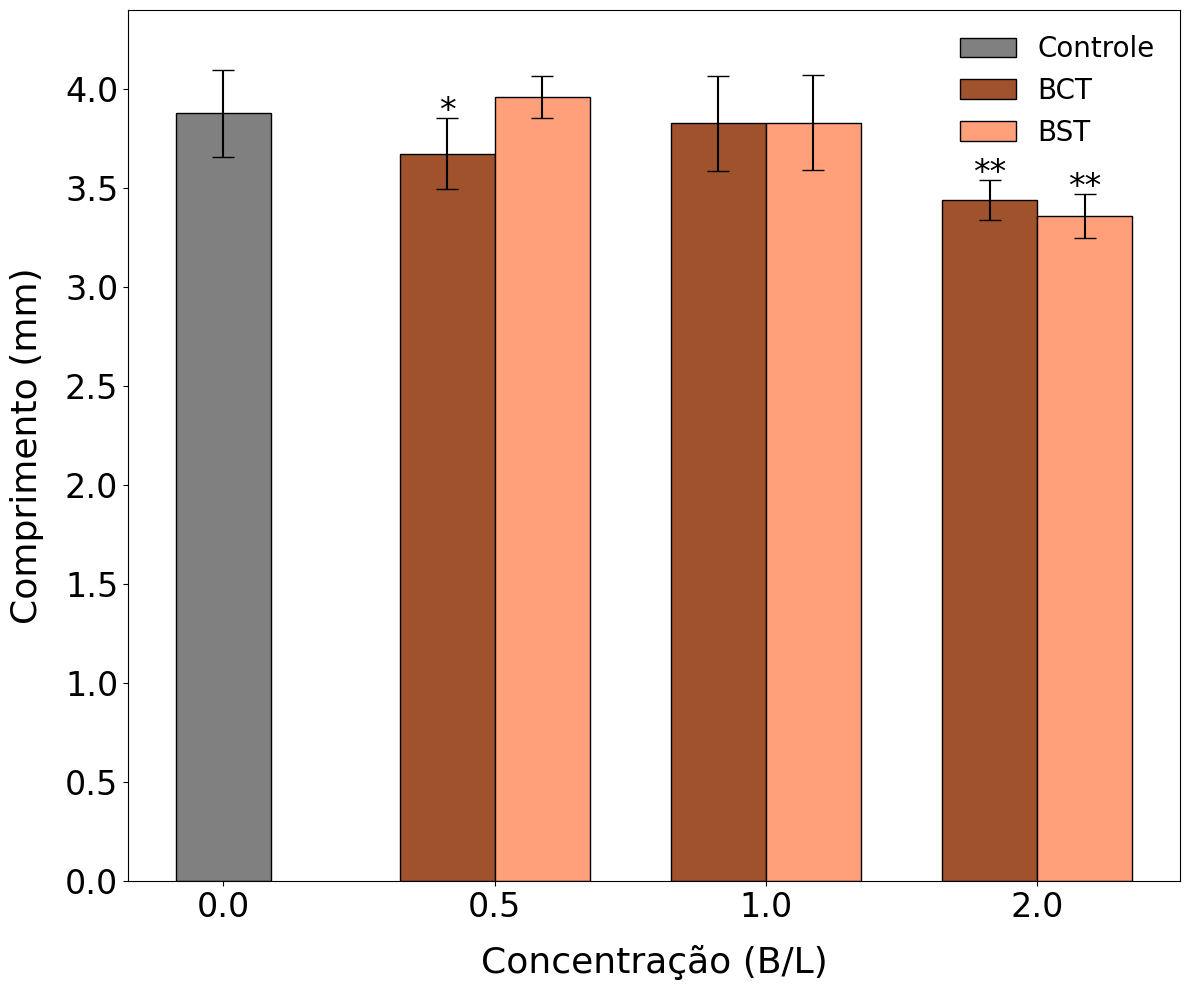

In [368]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Agrupar por type e concentration
df_plot = (
    df.groupby(['type', 'concentration'])['body_length']
      .agg(['mean', 'std'])
      .reset_index()
)

# Definir cores fixas
colors = {
    'control': 'gray',
    'BCT': 'sienna',
    'BST': 'lightsalmon'
}

# Separar controle dos tratamentos
control_data = df_plot[df_plot['type'].str.lower() == 'control']
treatments_data = df_plot[df_plot['type'].str.lower() != 'control']

# Pegar concentrações únicas (excluindo o controle)
concentrations = sorted(treatments_data['concentration'].unique())

# Definir largura e deslocamento das barras
bar_width = 0.35
x = np.arange(len(concentrations)) + 1  # começar do 1, porque 0 é o controle

fig, ax = plt.subplots(figsize=(12, 10))

# Plot controle no x=0
if not control_data.empty:
    c_mean = control_data['mean'].values[0]
    c_std = control_data['std'].values[0]
    ax.bar(
        0.0, c_mean, yerr=c_std, capsize=8,
        color=colors['control'], edgecolor='black',
        width=bar_width, label='Controle'
    )

# Plotar tratamentos lado a lado
for i, conc in enumerate(concentrations, start=1):
    # BCT
    bct_row = treatments_data[(treatments_data['type'] == 'BCT') & (treatments_data['concentration'] == conc)]
    if not bct_row.empty:
        ax.bar(
            i - bar_width/2, bct_row['mean'].values[0], 
            yerr=bct_row['std'].values[0], capsize=8,
            color=colors['BCT'], edgecolor='black',
            width=bar_width, label='BCT'
        )

    # BST
    bst_row = treatments_data[(treatments_data['type'] == 'BST') & (treatments_data['concentration'] == conc)]
    if not bst_row.empty:
        ax.bar(
            i + bar_width/2, bst_row['mean'].values[0], 
            yerr=bst_row['std'].values[0], capsize=8,
            color=colors['BST'], edgecolor='black',
            width=bar_width, label='BST'
        )

# Rótulos e eixos
ax.set_xlabel('Concentração (B/L)', fontsize=26, labelpad=15)
ax.set_ylabel('Comprimento (mm)', fontsize=26, labelpad=15)

# Colocar ticks no eixo X
ax.set_xticks([0.0] + list(np.arange(1, len(concentrations)+1)))
ax.set_xticklabels(['0.0'] + [str(c) for c in concentrations], fontsize=24)

ax.tick_params(axis='y', labelsize=24)

ax.set_ylim(0.0, 4.4)
# Adicionar asteriscos só em 0.5 e 2.0 do BCT e em 2.0 do BST
y_offset = 0
col = 'k'

for i, conc in enumerate(concentrations, start=1):
    # BCT em 0.5 e 2.0
    if conc in [0.5]:
        bct_row = treatments_data[(treatments_data['type'] == 'BCT') & (treatments_data['concentration'] == conc)]
        if not bct_row.empty:
            x_bct = i - bar_width/2
            y_bct = bct_row['mean'].values[0] + bct_row['std'].values[0] - 0.05
            ax.text(x_bct, y_bct + y_offset, "*", ha='center', va='bottom',
                    color=col, fontsize=24)

    if conc in [2.0]:
        bct_row = treatments_data[(treatments_data['type'] == 'BCT') & (treatments_data['concentration'] == conc)]
        if not bct_row.empty:
            x_bct = i - bar_width/2
            y_bct = bct_row['mean'].values[0] + bct_row['std'].values[0] - 0.05
            ax.text(x_bct, y_bct + y_offset, "**", ha='center', va='bottom',
                    color=col, fontsize=24)

    # BST em 2.0
    if conc == 2.0:
        bst_row = treatments_data[(treatments_data['type'] == 'BST') & (treatments_data['concentration'] == conc)]
        if not bst_row.empty:
            x_bst = i + bar_width/2
            y_bst = bst_row['mean'].values[0] + bst_row['std'].values[0] - 0.05
            ax.text(x_bst, y_bst + y_offset, "**", ha='center', va='bottom',
                    color=col, fontsize=24)

# Remover duplicatas da legenda
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
leg = ax.legend(by_label.values(), by_label.keys(), fontsize=20)
leg.get_frame().set_facecolor('none')   # fundo transparente
leg.get_frame().set_edgecolor('none')   # sem borda

plt.tight_layout()
plt.show()


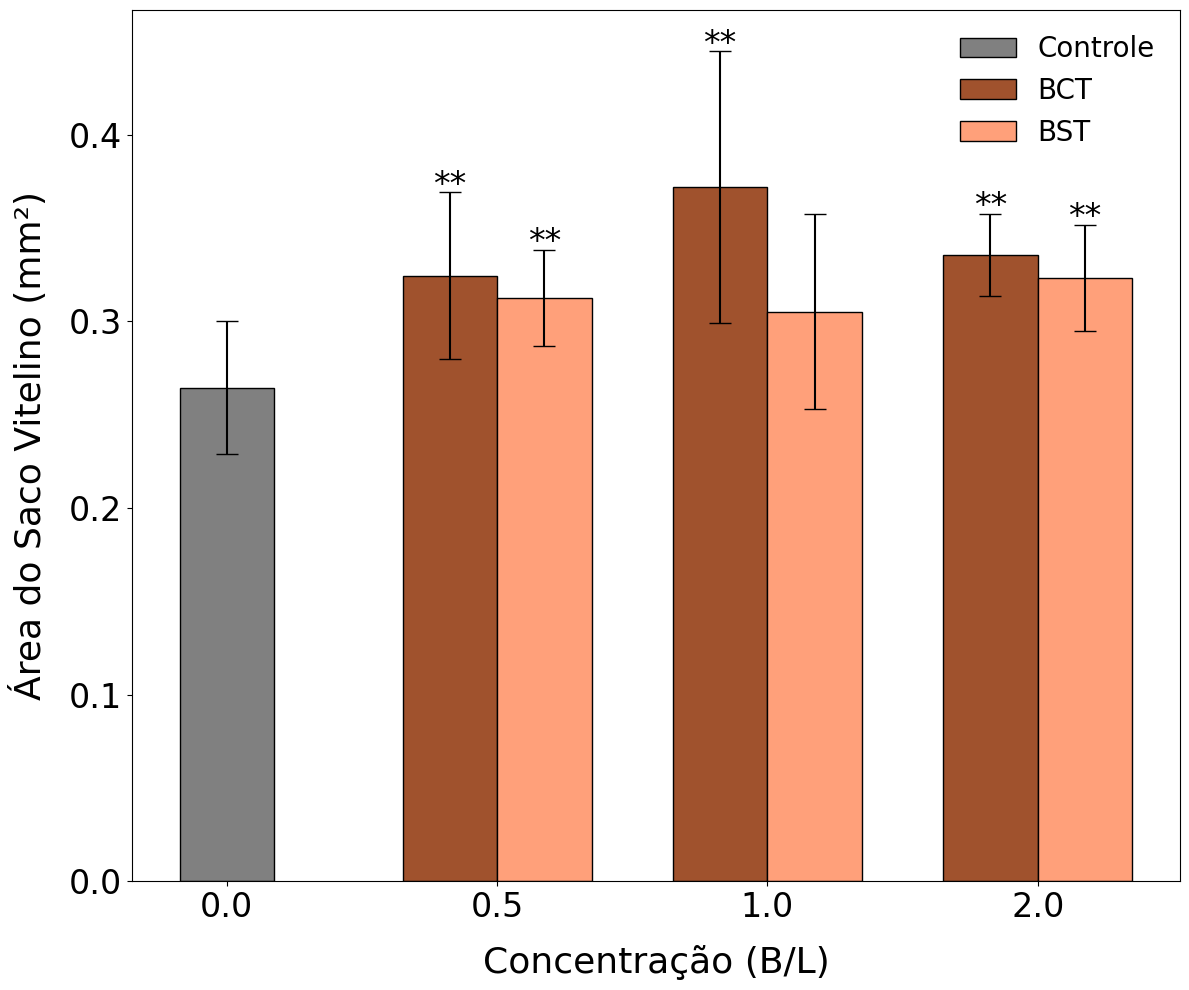

In [369]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Agrupar por type e concentration
df_plot = (
    df.groupby(['type', 'concentration'])['yolk_sac_area']
      .agg(['mean', 'std'])
      .reset_index()
)

# Definir cores fixas
colors = {
    'control': 'gray',
    'BCT': 'sienna',
    'BST': 'lightsalmon'
}

# Separar controle dos tratamentos
control_data = df_plot[df_plot['type'].str.lower() == 'control']
treatments_data = df_plot[df_plot['type'].str.lower() != 'control']

# Pegar concentrações únicas (excluindo o controle)
concentrations = sorted(treatments_data['concentration'].unique())

# Definir largura e deslocamento das barras
bar_width = 0.35
x = np.arange(len(concentrations)) + 1  # começar do 1, porque 0 é o controle

fig, ax = plt.subplots(figsize=(12, 10))

# Plot controle no x=0
if not control_data.empty:
    c_mean = control_data['mean'].values[0]
    c_std = control_data['std'].values[0]
    ax.bar(
        0.0, c_mean, yerr=c_std, capsize=8,
        color=colors['control'], edgecolor='black',
        width=bar_width, label='Controle'
    )

# Plotar tratamentos lado a lado
for i, conc in enumerate(concentrations, start=1):
    # BCT
    bct_row = treatments_data[(treatments_data['type'] == 'BCT') & (treatments_data['concentration'] == conc)]
    if not bct_row.empty:
        ax.bar(
            i - bar_width/2, bct_row['mean'].values[0], 
            yerr=bct_row['std'].values[0], capsize=8,
            color=colors['BCT'], edgecolor='black',
            width=bar_width, label='BCT'
        )

    # BST
    bst_row = treatments_data[(treatments_data['type'] == 'BST') & (treatments_data['concentration'] == conc)]
    if not bst_row.empty:
        ax.bar(
            i + bar_width/2, bst_row['mean'].values[0], 
            yerr=bst_row['std'].values[0], capsize=8,
            color=colors['BST'], edgecolor='black',
            width=bar_width, label='BST'
        )

# Rótulos e eixos
ax.set_xlabel('Concentração (B/L)', fontsize=26, labelpad=15)
ax.set_ylabel('Área do Saco Vitelino (mm²)', fontsize=26, labelpad=15)

# Colocar ticks no eixo X
ax.set_xticks([0.0] + list(np.arange(1, len(concentrations)+1)))
ax.set_xticklabels(['0.0'] + [str(c) for c in concentrations], fontsize=24)

ax.tick_params(axis='y', labelsize=24)

# Adicionar asteriscos apenas nos pontos especificados
y_offset = 0
col = 'k'

for i, conc in enumerate(concentrations, start=1):
    # BCT em 0.5, 1.0 e 2.0
    if conc in [0.5, 1.0, 2.0]:
        bct_row = treatments_data[(treatments_data['type'] == 'BCT') & (treatments_data['concentration'] == conc)]
        if not bct_row.empty:
            x_bct = i - bar_width/2
            y_bct = bct_row['mean'].values[0] + bct_row['std'].values[0] - 0.005
            ax.text(x_bct, y_bct + y_offset, "**", ha='center', va='bottom',
                    color=col, fontsize=24)

    # BST em 0.5 e 2.0
    if conc in [0.5, 2.0]:
        bst_row = treatments_data[(treatments_data['type'] == 'BST') & (treatments_data['concentration'] == conc)]
        if not bst_row.empty:
            x_bst = i + bar_width/2
            y_bst = bst_row['mean'].values[0] + bst_row['std'].values[0]  - 0.005
            ax.text(x_bst, y_bst + y_offset, "**", ha='center', va='bottom',
                    color=col, fontsize=24)

# Remover duplicatas da legenda
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
leg = ax.legend(by_label.values(), by_label.keys(), fontsize=20)
leg.get_frame().set_facecolor('none')   # fundo transparente
leg.get_frame().set_edgecolor('none')   # sem borda

plt.tight_layout()
plt.show()


,sample,type,concentration,bpm,body_length,yolk_sac_area,pigmented_area,open_swim_bladder,edema_present,deformation_present,aquisition_data,rep
0,1_bct_1,BCT,1.0,115,3.721,0.396,18096,no,no,no,2025-08-18T15:35:09.206382-03:00,1
1,2_bct_1,BCT,1.0,133,3.933,0.432,19992,no,no,no,2025-08-18T15:41:30.4801149-03:00,1
2,3_bct_1,BCT,1.0,149,3.690,0.245,23613,no,no,yes,2025-08-18T15:45:05.6896737-03:00,1
3,4_bct_1,BCT,1.0,124,3.909,0.362,27886,no,no,no,2025-08-18T15:49:14.9293665-03:00,1
4,5_bct_1,BCT,1.0,124,4.302,0.501,27014,no,no,no,2025-08-18T15:56:33.7860505-03:00,1
...,...,...,...,...,...,...,...,...,...,...,...,...
90,8_control,Control,0.0,152,3.849,0.266,11241,no,no,no,NaN,3
91,9_control,Control,0.0,172,3.971,0.326,13793,yes,no,no,NaN,3
92,10_control,Control,0.0,168,3.966,0.262,11152,no,no,no,NaN,3
93,11_control,Control,0.0,152,3.974,0.305,12402,yes,no,yes,NaN,3


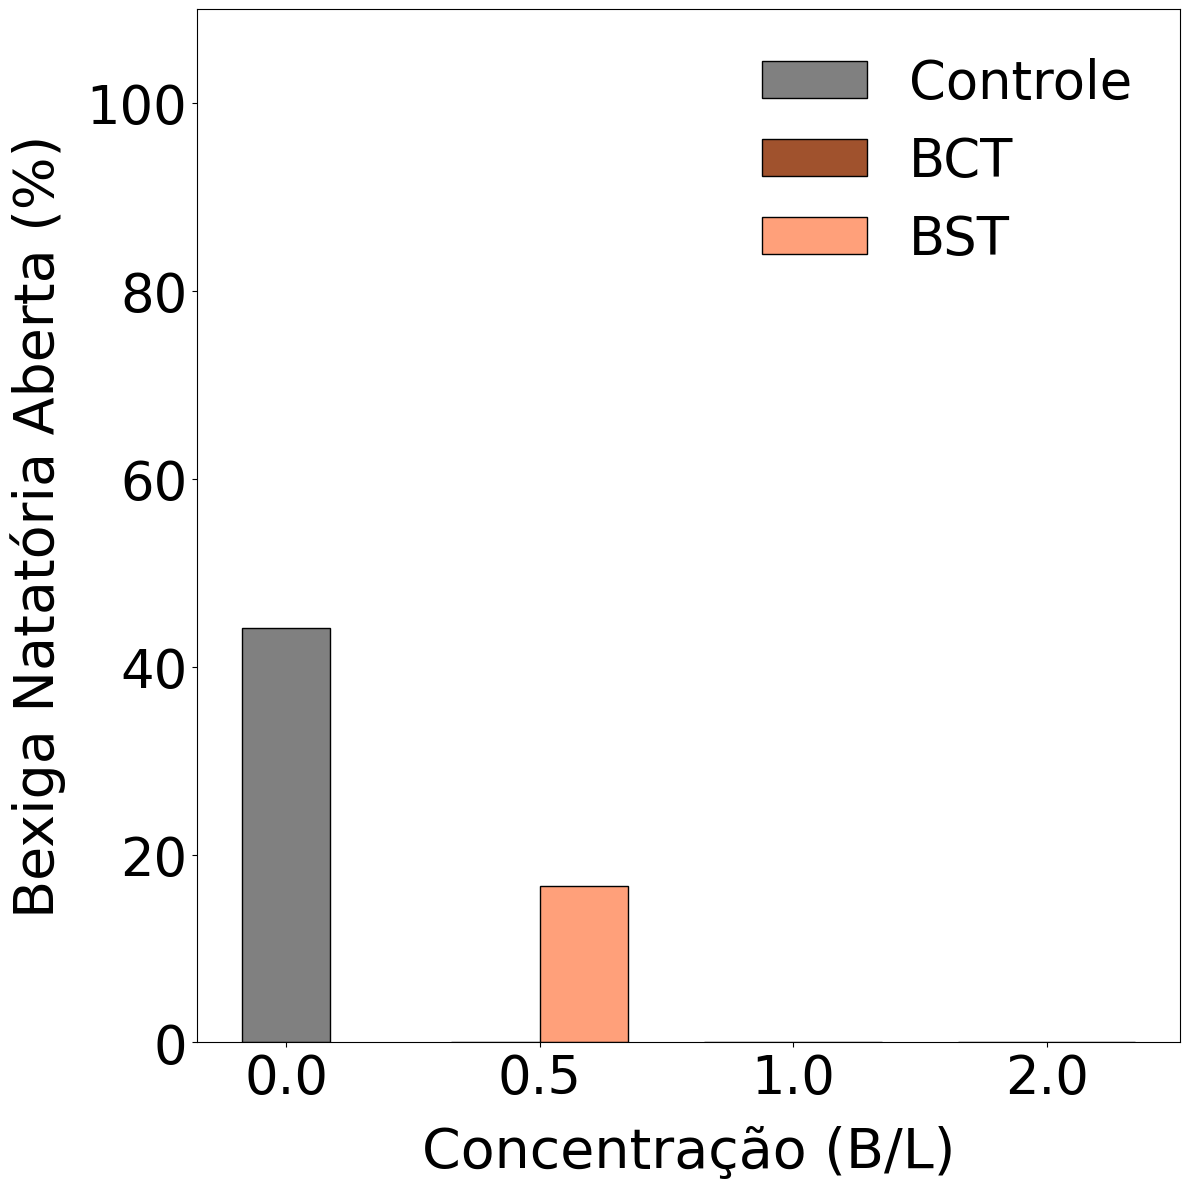

In [102]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Converter para minúsculo por segurança
df['open_swim_bladder'] = df['open_swim_bladder'].str.lower()

display(df)

# Calcular % de 'yes' por grupo
df_plot = (
    df.groupby(['type', 'concentration'])['open_swim_bladder']
      .apply(lambda x: (x.eq('yes').sum() / len(x)) * 100)
      .reset_index(name='percent_yes')
)

# Separar controle dos tratamentos
control_data = df_plot[df_plot['type'].str.lower() == 'control']
treatments_data = df_plot[df_plot['type'].str.lower() != 'control']

# Pegar concentrações únicas (excluindo o controle)
concentrations = sorted(treatments_data['concentration'].unique())

# Definir largura e deslocamento das barras
bar_width = 0.35
x = np.arange(len(concentrations)) + 1  # começar do 1, porque 0 é o controle

fig, ax = plt.subplots(figsize=(12, 12))

# Plot controle no x=0
if not control_data.empty:
    c_val = control_data['percent_yes'].values[0]
    ax.bar(
        0.0, c_val,
        color=colors['control'], edgecolor='black',
        width=bar_width, label='Controle'
    )

# Plotar tratamentos lado a lado
for i, conc in enumerate(concentrations, start=1):
    # BCT
    bct_row = treatments_data[(treatments_data['type'] == 'BCT') & 
                              (treatments_data['concentration'] == conc)]
    if not bct_row.empty:
        ax.bar(
            i - bar_width/2, bct_row['percent_yes'].values[0],
            color=colors['BCT'], edgecolor='black',
            width=bar_width, label='BCT'
        )

    # BST
    bst_row = treatments_data[(treatments_data['type'] == 'BST') & 
                              (treatments_data['concentration'] == conc)]
    if not bst_row.empty:
        ax.bar(
            i + bar_width/2, bst_row['percent_yes'].values[0],
            color=colors['BST'], edgecolor='black',
            width=bar_width, label='BST'
        )

# Rótulos e eixos
ax.set_xlabel('Concentração (B/L)', fontsize=40, labelpad=15)
ax.set_ylabel('Bexiga Natatória Aberta (%)', fontsize=40, labelpad=15)

# Colocar ticks no eixo X
ax.set_xticks([0.0] + list(np.arange(1, len(concentrations)+1)))
ax.set_xticklabels(['0.0'] + [str(c) for c in concentrations], fontsize=38)

ax.set_ylim(0, 110)
ax.tick_params(axis='y', labelsize=38)

# Remover duplicatas da legenda
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
leg = ax.legend(by_label.values(), by_label.keys(), fontsize=38)
leg.get_frame().set_facecolor('none')
leg.get_frame().set_edgecolor('none')

plt.tight_layout()
plt.show()

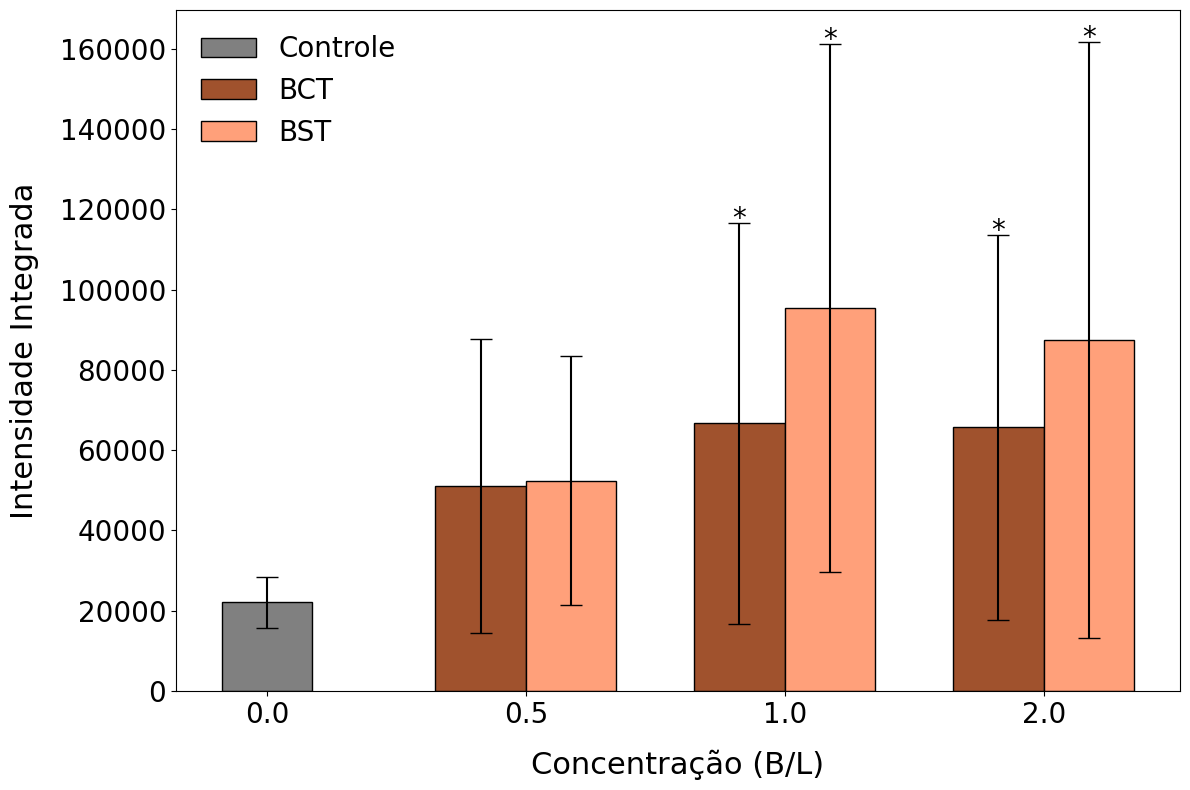

In [376]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df1 = pd.read_excel('../ROS/dataset_ros_geral.xlsx')

# Agrupar por type e concentration
df_plot = (
    df1.groupby(['type', 'concentration'])['intensity']
      .agg(['mean', 'std'])
      .reset_index()
)

# Definir cores fixas
colors = {
    'control': 'gray',
    'BCT': 'sienna',
    'BST': 'lightsalmon'
}

# Separar controle dos tratamentos
control_data = df_plot[df_plot['type'].str.lower() == 'control']
treatments_data = df_plot[df_plot['type'].str.lower() != 'control']

# Pegar concentrações únicas (excluindo o controle)
concentrations = sorted(treatments_data['concentration'].unique())

# Criar posições igualmente espaçadas para cada concentração
positions = {conc: i for i, conc in enumerate(concentrations, start=1)}

# Largura das barras
bar_width = 0.35

fig, ax = plt.subplots(figsize=(12, 8))

# ======================
# PLOTAR CONTROLE (posição 0)
# ======================
if not control_data.empty:
    c_mean = control_data['mean'].values[0]
    c_std = control_data['std'].values[0]
    ax.bar(
        0, c_mean, yerr=c_std, capsize=8,
        color=colors['control'], edgecolor='black',
        width=bar_width, label='Controle'
    )

# ======================
# PLOTAR TRATAMENTOS COM POSIÇÕES IGUAIS ENTRE CONC.
# ======================
# ======================
for conc in concentrations:
    base_x = positions[conc]

    # BCT
    bct_row = treatments_data[(treatments_data['type'] == 'BCT') &
                              (treatments_data['concentration'] == conc)]
    if not bct_row.empty:
        mean_val = bct_row['mean'].values[0]
        std_val = bct_row['std'].values[0]
        xpos = base_x - bar_width/2

        ax.bar(
            xpos, mean_val,
            yerr=std_val, capsize=8,
            color=colors['BCT'], edgecolor='black',
            width=bar_width, label='BCT'
        )

        # ⭐ Asterisco somente para concentrações 1.0 e 2.0
        if conc in [1.0, 2.0]:
            ax.text(
                xpos, mean_val + std_val - 2500, "*",
                ha='center', va='bottom', color='k', fontsize=20
            )

    # BST
    bst_row = treatments_data[(treatments_data['type'] == 'BST') &
                              (treatments_data['concentration'] == conc)]
    if not bst_row.empty:
        mean_val = bst_row['mean'].values[0]
        std_val = bst_row['std'].values[0]
        xpos = base_x + bar_width/2

        ax.bar(
            xpos, mean_val,
            yerr=std_val, capsize=8,
            color=colors['BST'], edgecolor='black',
            width=bar_width, label='BST'
        )

        # ⭐ Asterisco somente para concentrações 1.0 e 2.0
        if conc in [1.0, 2.0]:
            ax.text(
                xpos, mean_val + std_val - 2500, "*",
                ha='center', va='bottom', color='k', fontsize=20
            )


# ======================
# RÓTULOS E EIXOS
# ======================
ax.set_xlabel('Concentração (B/L)', fontsize=22, labelpad=15)
ax.set_ylabel('Intensidade Integrada', fontsize=22, labelpad=15)

# Ticks igualmente espaçados, mas com rótulos reais
xticks_vals = [0] + list(positions.values())
xticks_labels = ["0.0"] + [str(c) for c in concentrations]

ax.set_xticks(xticks_vals)
ax.set_xticklabels(xticks_labels, fontsize=20)

ax.tick_params(axis='y', labelsize=20)

# Legenda sem duplicatas
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
leg = ax.legend(by_label.values(), by_label.keys(), fontsize=20)
leg.get_frame().set_facecolor('none')
leg.get_frame().set_edgecolor('none')

plt.tight_layout()
plt.show()


,sample,type,concentration,bpm,body_length,yolk_sac_area,pigmented_area,open_swim_bladder,edema_present,deformation_present,aquisition_data,rep
0,1_bct_1,BCT,1.0,115,3.721,0.396,18096,no,no,no,2025-08-18T15:35:09.206382-03:00,1
1,2_bct_1,BCT,1.0,133,3.933,0.432,19992,no,no,no,2025-08-18T15:41:30.4801149-03:00,1
2,3_bct_1,BCT,1.0,149,3.690,0.245,23613,no,no,yes,2025-08-18T15:45:05.6896737-03:00,1
3,4_bct_1,BCT,1.0,124,3.909,0.362,27886,no,no,no,2025-08-18T15:49:14.9293665-03:00,1
4,5_bct_1,BCT,1.0,124,4.302,0.501,27014,no,no,no,2025-08-18T15:56:33.7860505-03:00,1
...,...,...,...,...,...,...,...,...,...,...,...,...
90,8_control,Control,0.0,152,3.849,0.266,11241,no,no,no,NaN,3
91,9_control,Control,0.0,172,3.971,0.326,13793,yes,no,no,NaN,3
92,10_control,Control,0.0,168,3.966,0.262,11152,no,no,no,NaN,3
93,11_control,Control,0.0,152,3.974,0.305,12402,yes,no,yes,NaN,3


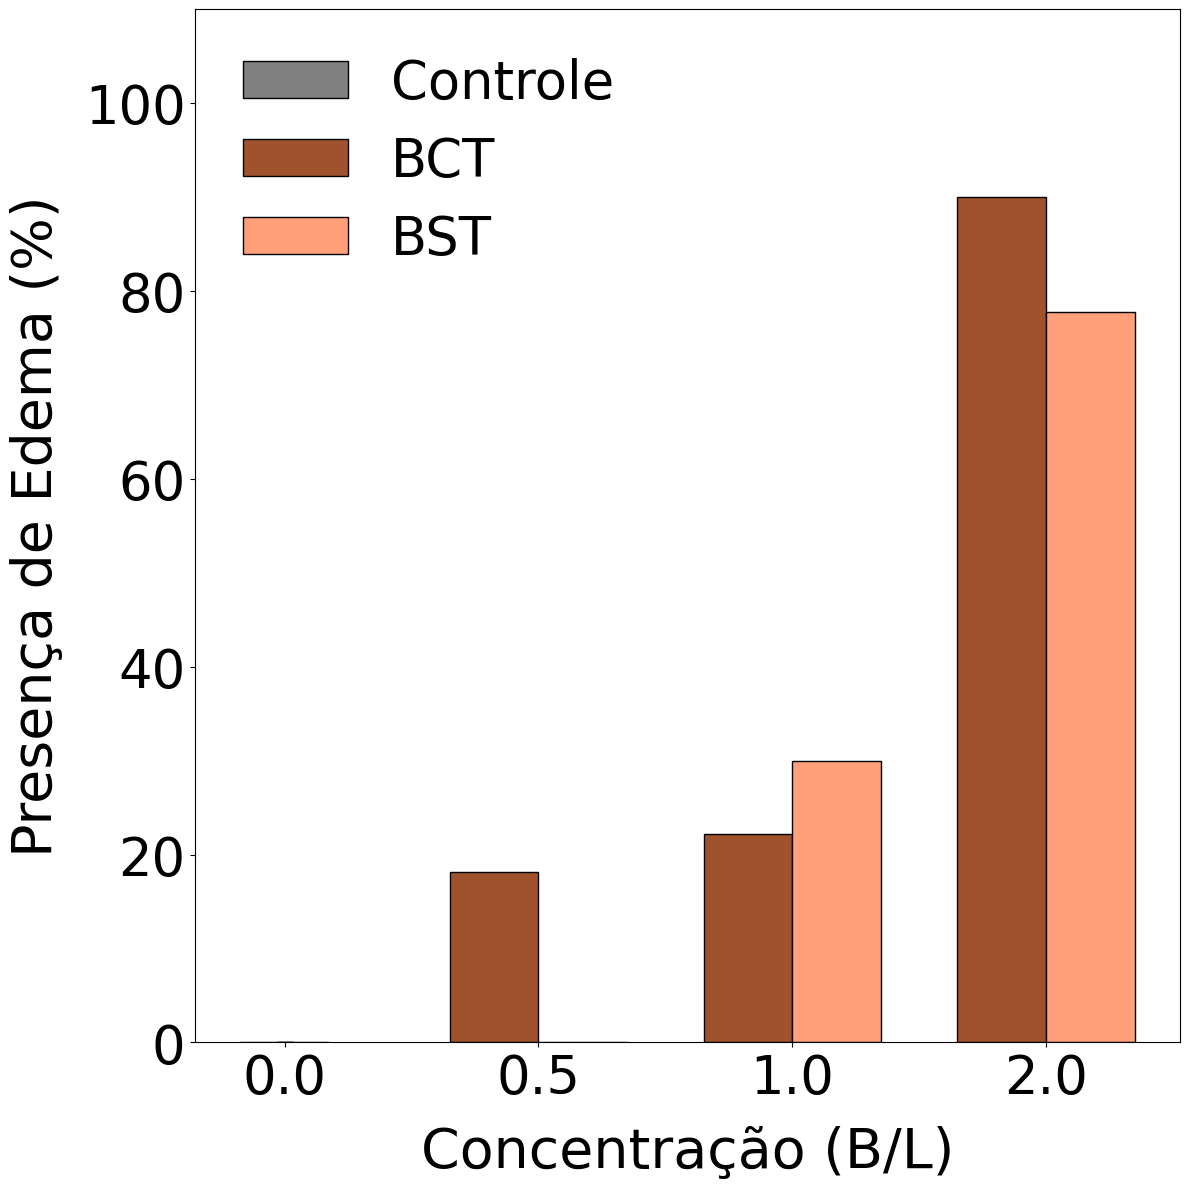

In [103]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = df.copy()

display(df)

df.loc[0:30,  'rep'] = 1
df.loc[31:59, 'rep'] = 2
df.loc[60:94, 'rep'] = 3
df['rep'] = df['rep'].astype(int)

df['edema_present'] = df['edema_present'].str.lower()

df_rep = (
    df.groupby(['type', 'concentration', 'rep'])['edema_present']
      .apply(lambda x: (x.eq('yes').sum() / len(x)) * 100)
      .reset_index(name='percent_yes')
)

df_stats = (
    df_rep.groupby(['type', 'concentration'])['percent_yes']
          .agg(['mean', 'std'])
          .reset_index()
)

control = df_stats[df_stats['type'].str.lower() == 'control']
treat = df_stats[df_stats['type'].str.lower() != 'control']

concentrations = sorted(treat['concentration'].unique())

bar_width = 0.35
x = np.arange(len(concentrations)) + 1

fig, ax = plt.subplots(figsize=(12, 12))

if not control.empty:
    c_mean = control['mean'].values[0]
    c_sd   = control['std'].values[0]
    ax.bar(
        0.0, c_mean, width=bar_width,
        color=colors['control'], edgecolor='black',
        label='Controle'
    )
    ax.errorbar(0.0, c_mean, yerr=c_sd, fmt='none', ecolor='black', capsize=6)

for i, conc in enumerate(concentrations, start=1):

    row = df_stats[(df_stats['type']=='BCT') & (df_stats['concentration']==conc)]
    if not row.empty:
        ax.bar(
            i - bar_width/2, row['mean'].values[0],
            width=bar_width, color=colors['BCT'], edgecolor='black',
            label='BCT'
        )
        ax.errorbar(
            i - bar_width/2, row['mean'], yerr=row['std'],
            fmt='none', ecolor='black', capsize=6
        )

    row = df_stats[(df_stats['type']=='BST') & (df_stats['concentration']==conc)]
    if not row.empty:
        ax.bar(
            i + bar_width/2, row['mean'].values[0],
            width=bar_width, color=colors['BST'], edgecolor='black',
            label='BST'
        )
        ax.errorbar(
            i + bar_width/2, row['mean'], yerr=row['std'],
            fmt='none', ecolor='black', capsize=6
        )

ax.set_xlabel('Concentração (B/L)', fontsize=40, labelpad=15)
ax.set_ylabel('Presença de Edema (%)', fontsize=40, labelpad=15)

ax.set_xticks([0.0] + list(np.arange(1, len(concentrations)+1)))
ax.set_xticklabels(['0.0'] + [str(c) for c in concentrations], fontsize=38)

ax.set_ylim(0, 110)
ax.tick_params(axis='y', labelsize=38)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
leg = ax.legend(by_label.values(), by_label.keys(), fontsize=38)
leg.get_frame().set_facecolor('none')
leg.get_frame().set_edgecolor('none')

plt.tight_layout()
plt.show()


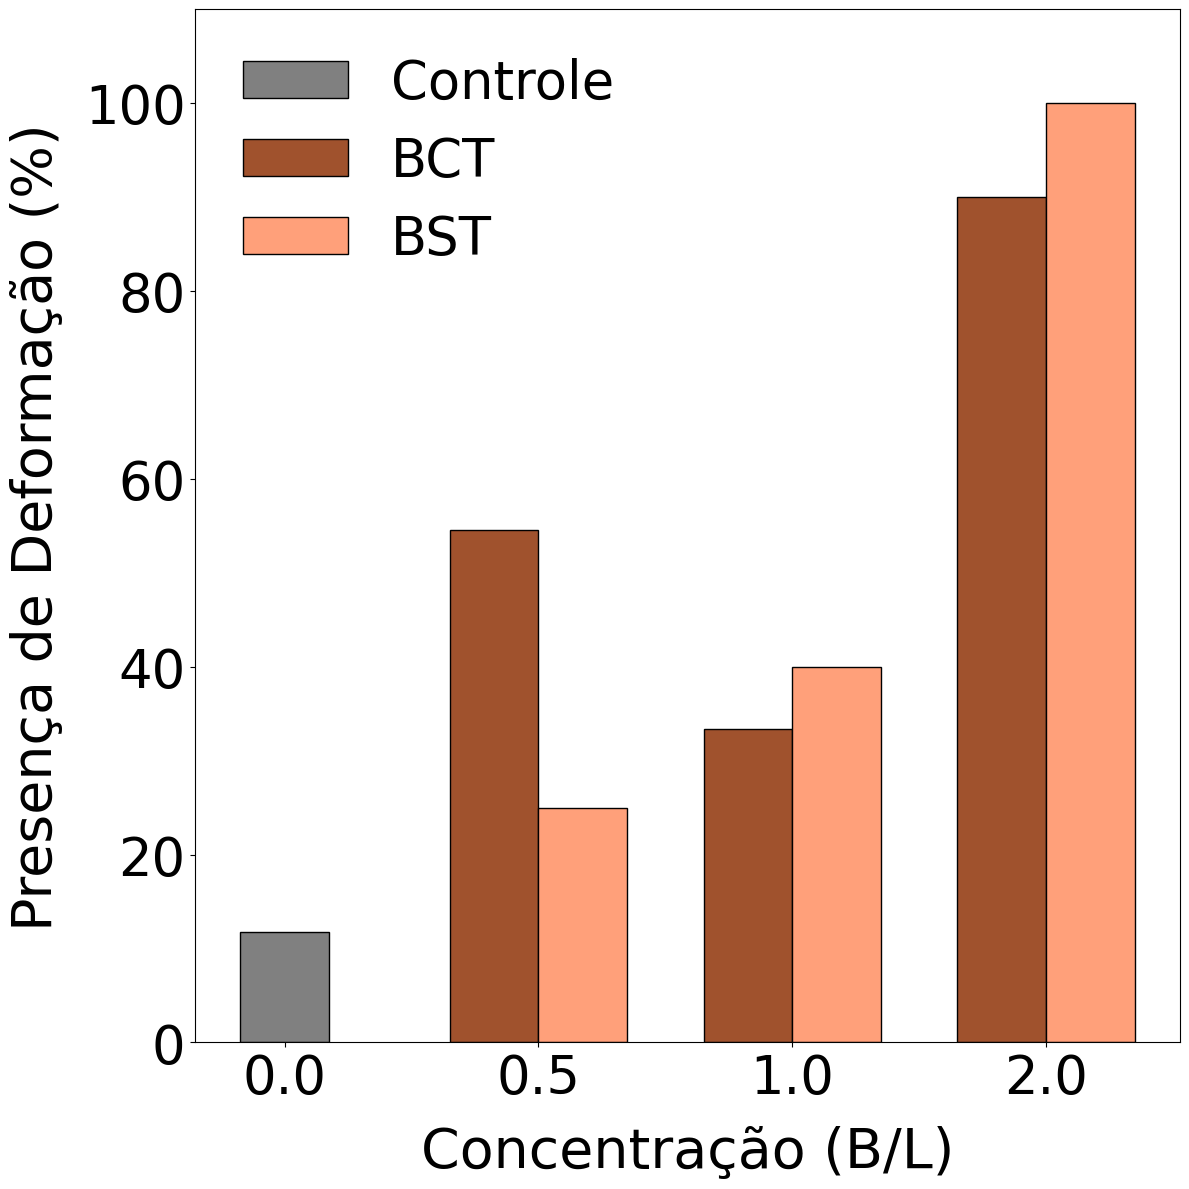

In [105]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Converter para minúsculo por segurança
df['deformation_present'] = df['deformation_present'].str.lower()

# Calcular % de 'yes' por grupo
df_plot = (
    df.groupby(['type', 'concentration'])['deformation_present']
      .apply(lambda x: (x.eq('yes').sum() / len(x)) * 100)
      .reset_index(name='percent_yes')
)

# Separar controle dos tratamentos
control_data = df_plot[df_plot['type'].str.lower() == 'control']
treatments_data = df_plot[df_plot['type'].str.lower() != 'control']

# Pegar concentrações únicas (excluindo o controle)
concentrations = sorted(treatments_data['concentration'].unique())

# Definir largura e deslocamento das barras
bar_width = 0.35
x = np.arange(len(concentrations)) + 1  # começar do 1, porque 0 é o controle

fig, ax = plt.subplots(figsize=(12, 12))

# Plot controle no x=0
if not control_data.empty:
    c_val = control_data['percent_yes'].values[0]
    ax.bar(
        0.0, c_val,
        color=colors['control'], edgecolor='black',
        width=bar_width, label='Controle'
    )

# Plotar tratamentos lado a lado
for i, conc in enumerate(concentrations, start=1):
    # BCT
    bct_row = treatments_data[(treatments_data['type'] == 'BCT') & (treatments_data['concentration'] == conc)]
    if not bct_row.empty:
        ax.bar(
            i - bar_width/2, bct_row['percent_yes'].values[0],
            color=colors['BCT'], edgecolor='black',
            width=bar_width, label='BCT'
        )

    # BST
    bst_row = treatments_data[(treatments_data['type'] == 'BST') & (treatments_data['concentration'] == conc)]
    if not bst_row.empty:
        ax.bar(
            i + bar_width/2, bst_row['percent_yes'].values[0],
            color=colors['BST'], edgecolor='black',
            width=bar_width, label='BST'
        )

# Rótulos e eixos
ax.set_xlabel('Concentração (B/L)', fontsize=40, labelpad=15)
ax.set_ylabel('Presença de Deformação (%)', fontsize=40, labelpad=15)

# Colocar ticks no eixo X
ax.set_xticks([0.0] + list(np.arange(1, len(concentrations)+1)))
ax.set_xticklabels(['0.0'] + [str(c) for c in concentrations], fontsize=38)

ax.set_ylim(0, 110)  # até 100% (um pouco de espaço acima)
ax.tick_params(axis='y', labelsize=38)

# Remover duplicatas da legenda
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
leg = ax.legend(by_label.values(), by_label.keys(), fontsize=38)
leg.get_frame().set_facecolor('none')
leg.get_frame().set_edgecolor('none')

plt.tight_layout()
plt.show()

,type,concentration,mean,std
0,BCT,1,66658.666667,49988.023795
1,BCT,2,65720.909091,47895.153962
2,BST,1,95389.222222,65785.866660
3,BST,2,87392.357143,74136.100430
4,control,0,44198.555556,66484.916214


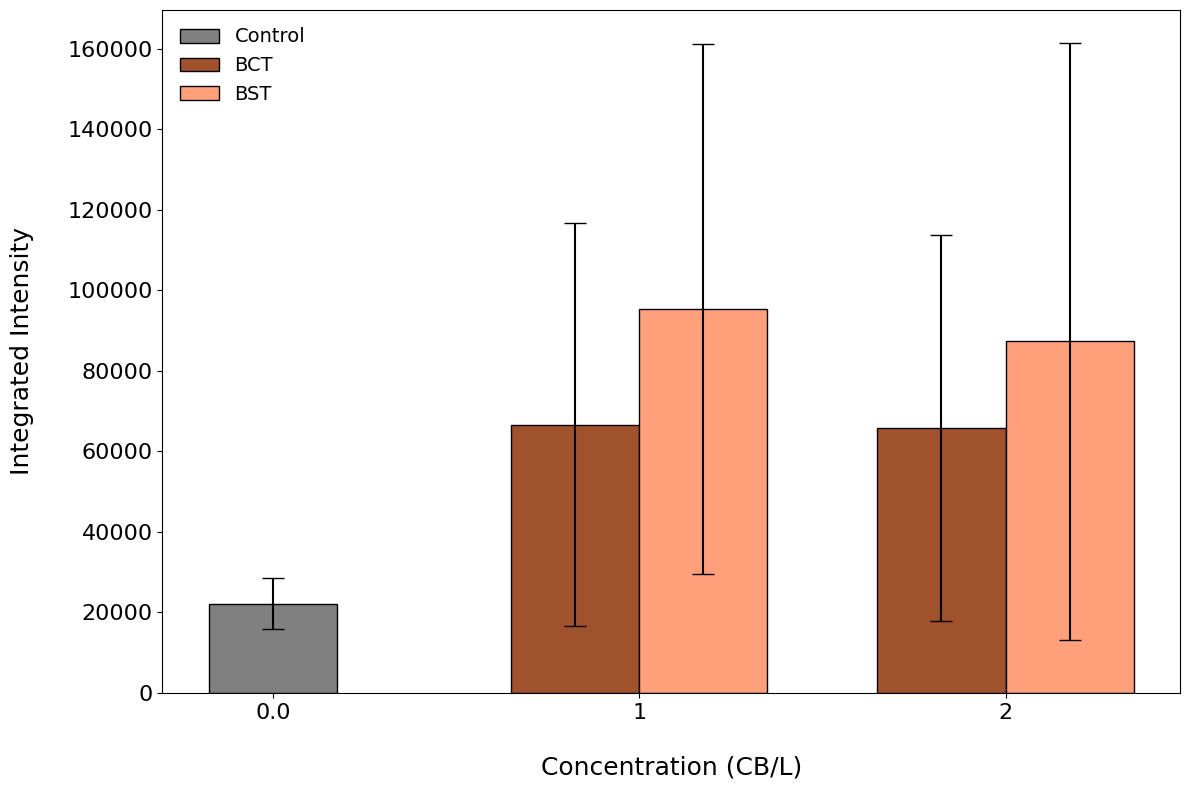

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_ros = pd.read_excel('../ROS/22082025/dataset_ros.xlsx')

df_ros = df_ros[df_ros['sample'] != 'Snap-19']

display(df_plot)

# Agrupar por type e concentration
df_plot = (
    df_ros.groupby(['type', 'concentration'])['intensity']
      .agg(['mean', 'std'])
      .reset_index()
)



# Separar controle dos tratamentos
control_data = df_plot[df_plot['type'].str.lower() == 'control']
treatments_data = df_plot[df_plot['type'].str.lower() != 'control']

# Pegar concentrações únicas (excluindo o controle)
concentrations = sorted(treatments_data['concentration'].unique())

# Definir largura e deslocamento das barras
bar_width = 0.35
x = np.arange(len(concentrations)) + 1  # começar do 1, porque 0 é o controle

fig, ax = plt.subplots(figsize=(12, 8))

# Plot controle no x=0
if not control_data.empty:
    c_mean = control_data['mean'].values[0]
    c_std = control_data['std'].values[0]
    ax.bar(
        0.0, c_mean, yerr=c_std, capsize=8,
        color=colors['control'], edgecolor='black',
        width=bar_width, label='Control'
    )

# Plotar tratamentos lado a lado
for i, conc in enumerate(concentrations, start=1):
    # BCT
    bct_row = treatments_data[(treatments_data['type'] == 'BCT') & (treatments_data['concentration'] == conc)]
    if not bct_row.empty:
        ax.bar(
            i - bar_width/2, bct_row['mean'].values[0], 
            yerr=bct_row['std'].values[0], capsize=8,
            color=colors['BCT'], edgecolor='black',
            width=bar_width, label='BCT'
        )

    # BST
    bst_row = treatments_data[(treatments_data['type'] == 'BST') & (treatments_data['concentration'] == conc)]
    if not bst_row.empty:
        ax.bar(
            i + bar_width/2, bst_row['mean'].values[0], 
            yerr=bst_row['std'].values[0], capsize=8,
            color=colors['BST'], edgecolor='black',
            width=bar_width, label='BST'
        )

# Rótulos e eixos
ax.set_xlabel('\nConcentration (CB/L)', fontsize=18)
ax.set_ylabel('Integrated Intensity\n', fontsize=18)

# Colocar ticks no eixo X
ax.set_xticks([0.0] + list(np.arange(1, len(concentrations)+1)))
ax.set_xticklabels(['0.0'] + [str(c) for c in concentrations], fontsize=16)

ax.tick_params(axis='y', labelsize=16)

# Remover duplicatas da legenda
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
leg = ax.legend(by_label.values(), by_label.keys(), fontsize=14)
leg.get_frame().set_facecolor('none')   # fundo transparente
leg.get_frame().set_edgecolor('none')   # sem borda

plt.tight_layout()
plt.show()


In [48]:
df_ros

,sample,type,concentration,intensity
0,Snap-13,control,0,27157
1,Snap-15,control,0,17222
2,Snap-17,control,0,19979
3,Snap-19,control,0,220784
4,Snap-22,control,0,22546
5,Snap-24,control,0,32644
6,Snap-26,control,0,25226
7,Snap-28,control,0,11927
8,Snap-30,control,0,20302
9,Snap-108,BCT,1,182270


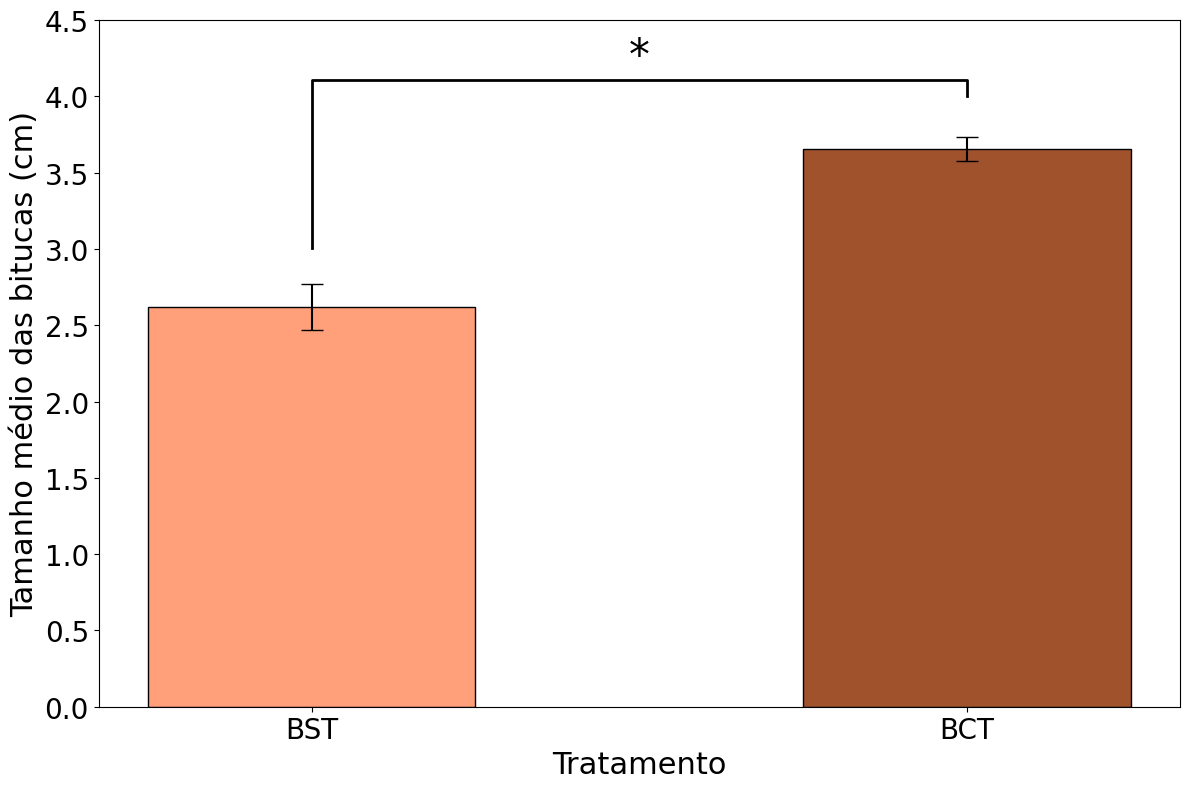

In [367]:
import matplotlib.pyplot as plt
import numpy as np

bst = [2.841, 2.561, 2.537, 2.329, 2.761, 2.692, 2.568, 2.761, 2.519, 2.628]
bct = [3.551, 3.638, 3.638, 3.649, 3.692, 3.722, 3.643, 3.652, 3.548, 3.818]

means = [np.mean(bst), np.mean(bct)]
stds = [np.std(bst, ddof=1), np.std(bct, ddof=1)]

labels = ['BST', 'BCT']
colors = ['lightsalmon', 'sienna']

fig, ax = plt.subplots(figsize=(12, 8))

ax.bar(labels, means, yerr=stds, capsize=8, color=colors, edgecolor='black', width=0.5)

plt.ylim(0.0, 4.5)
ax.set_ylabel('Tamanho médio das bitucas (cm)', fontsize=22)
ax.set_xlabel('Tratamento', fontsize=22)
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=20)

x1, x2 = 0, 1
y = max(means) + max(stds) + 0.2
h = 0.1
ax.plot([x1, x1, x2, x2], [y-1.0, y+h, y+h, y], color='black', linewidth=2)
ax.text((x1 + x2) * 0.5, y + h + 0.02, '*', ha='center', va='bottom', fontsize=30)

plt.tight_layout()
plt.show()


In [191]:

# Caminho do seu arquivo TXT
arquivo = "spectrum_bct.txt"

# Palavras-chave
inicio = "#SPECTRUM    : Spectral Data Starts Here"
fim     = "#ENDOFDATA   :"

# Ler o arquivo inteiro
with open(arquivo, "r", encoding="utf-8", errors="ignore") as f:
    linhas = f.readlines()

# Extrair somente a parte entre SPECTRUM e ENDOFDATA
dados_txt_bct = []
capturar = False

for linha in linhas:
    linha = linha.strip()

    if inicio in linha:
        capturar = True
        continue
    if fim in linha:
        capturar = False
        break

    if capturar:
        if "," in linha:
            x_str, y_str = linha.split(",")
            dados_txt_bct.append([float(x_str), float(y_str)])


In [244]:
df_EDS_bct = pd.read_excel('eds.xlsx', sheet_name='BCT')

df_EDS_bct_elementos = df_EDS_bct.dropna()

df_EDS_bct = pd.DataFrame(dados_txt_bct, columns=["x", "y"])

df_EDS_bct['y'] = df_EDS_bct['y'] / 4250
df_EDS_bct_elementos.loc[
    df_EDS_bct_elementos['kev_element'] > 1.0, 
    'kev_element'
] = df_EDS_bct_elementos.loc[
    df_EDS_bct_elementos['kev_element'] > 1.0, 
    'kev_element'
] / 1000

df_EDS_bct_elementos = df_EDS_bct_elementos[df_EDS_bct_elementos['kev_element'] <= 10.0]

df_EDS_bct_elementos['n_element'] = df_EDS_bct_elementos['n_element'].astype(int)

display(df_EDS_bct)

df_EDS_bct_elementos = df_EDS_bct_elementos.drop(43)

display(df_EDS_bct_elementos)

,x,y
0,-0.20,0.000000
1,-0.19,0.000000
2,-0.18,0.000000
3,-0.17,0.000000
4,-0.16,0.000000
...,...,...
2043,20.23,0.018588
2044,20.24,0.023529
2045,20.25,0.018353
2046,20.26,0.019294


,n_element,kev_element,elemento,x,y
0,8,0.525,O,-0.20,0.0
1,11,1.041,Na,-0.19,0.0
2,12,1.254,Mg,-0.18,0.0
3,16,2.308,S,-0.17,0.0
4,16,2.464,S,-0.16,0.0
5,17,2.622,Cl,-0.15,0.0
6,17,2.816,Cl,-0.14,0.0
7,17,0.181,Cl,-0.13,0.0
8,19,3.314,K,-0.12,0.0
9,19,3.590,K,-0.11,0.0


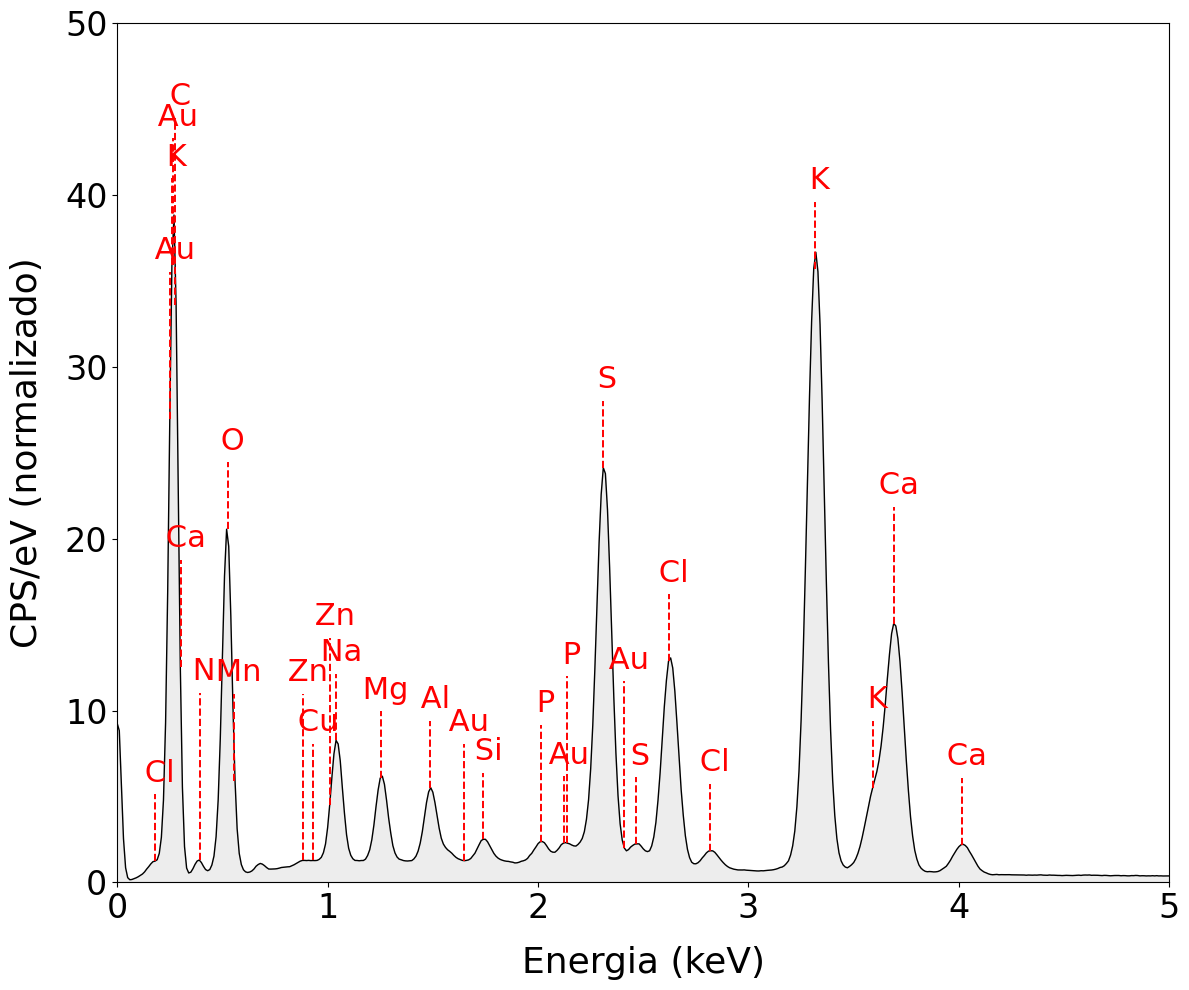

In [370]:
import matplotlib.pyplot as plt

# Dados do espectro
eds_bct_dados = df_EDS_bct[['x','y']]
x_bct_eds = eds_bct_dados['x'].values
y_bct_eds = eds_bct_dados['y'].values

plt.figure(figsize=(12, 10))
plt.plot(x_bct_eds, y_bct_eds, linewidth=1, color="black")
plt.fill_between(x_bct_eds, y_bct_eds, 0, color="lightgray", alpha=0.4)

plt.xlabel("Energia (keV)", fontsize=26, labelpad=15)
plt.ylabel("CPS/eV (normalizado)", fontsize=26, labelpad=15)
#plt.title('EDS - BCT', fontsize=26, pad=15)

posicoes_x_usadas = []


for _, row in df_EDS_bct_elementos.iterrows():
    energia = row['kev_element']
    
    # Encontrar valor Y do espectro
    idx = (abs(x_bct_eds - energia)).argmin()
    y_val = y_bct_eds[idx]

    if y_val < 1.2:
        continue

    elemento = row['elemento']
    numero = row['n_element']
    texto = fr"{elemento}"

    y_top = y_val + (y_bct_eds.max() * 0.1)

    # aumentar linha se houver rótulos muito próximos
    for energia_prev in posicoes_x_usadas:
        if abs(energia - energia_prev) < 0.15 and energia <0.75:
            y_top += y_bct_eds.max() * 0.03 # sobe mais uma "camada"
        elif abs(energia - energia_prev) < 0.15 and energia >0.75:
            y_top += y_bct_eds.max() * 0.075  # sobe mais uma "camada"

    posicoes_x_usadas.append(energia)

    # Desenhar a linha vertical ("stem")
    plt.vlines(
        energia,
        y_val,
        y_top,
        color="red",
        linewidth=1.4,
        linestyles='--'
    )

    # Adicionar o nome do elemento no topo da linha
    plt.text(
        energia,
        y_top + (y_bct_eds.max() * 0.01),
        texto,
        ha='center',
        va='bottom',
        fontsize=22,
        color='red',
        rotation=0,
    )


plt.xlim(0, 5)
plt.ylim(0, 50)
plt.tick_params(axis='y', labelsize=24)
plt.tick_params(axis='x', labelsize=24)
plt.tight_layout()
plt.show()


In [246]:
# Caminho do seu arquivo TXT
arquivo = "spectrum_bst.txt"

# Palavras-chave
inicio = "#SPECTRUM    : Spectral Data Starts Here"
fim     = "#ENDOFDATA   :"

# Ler o arquivo inteiro
with open(arquivo, "r", encoding="utf-8", errors="ignore") as f:
    linhas = f.readlines()

# Extrair somente a parte entre SPECTRUM e ENDOFDATA
dados_txt_bst = []
capturar = False

for linha in linhas:
    linha = linha.strip()

    if inicio in linha:
        capturar = True
        continue
    if fim in linha:
        capturar = False
        break

    if capturar:
        if "," in linha:
            x_str, y_str = linha.split(",")
            dados_txt_bst.append([float(x_str), float(y_str)])


,n_element,kev_element,elemento,x,y
0,6,0.277,C,-0.20,0.0
1,8,0.525,O,-0.19,0.0
2,11,1.041,Na,-0.18,0.0
3,12,1.254,Mg,-0.17,0.0
4,14,1.740,Si,-0.16,0.0
5,17,2.622,Cl,-0.15,0.0
6,17,2.816,Cl,-0.14,0.0
7,17,0.181,Cl,-0.13,1.0
8,20,3.692,Ca,-0.12,0.0
9,20,4.013,Ca,-0.11,0.0


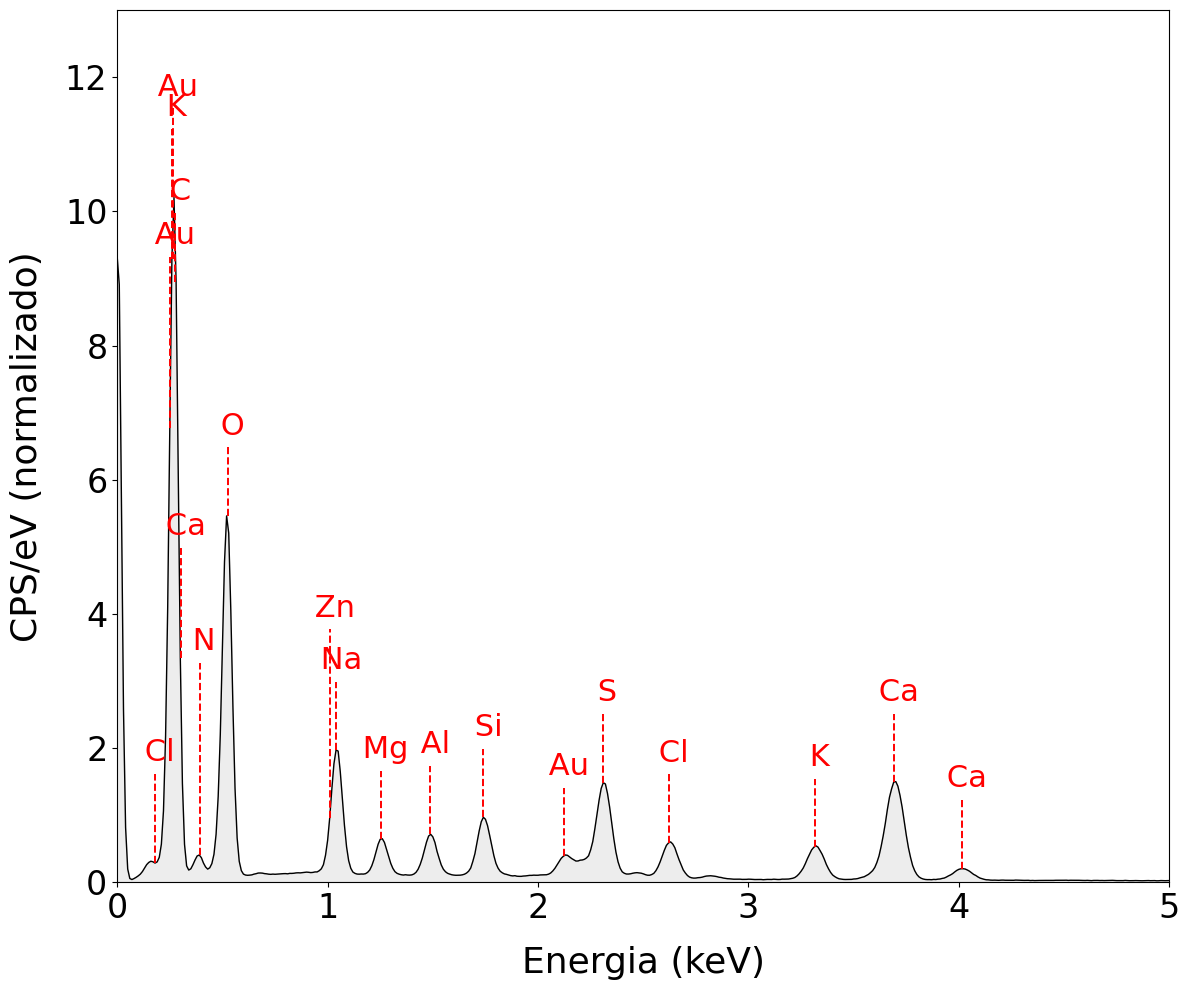

In [371]:
df_EDS_bst = pd.read_excel('eds.xlsx', sheet_name='BST')
df_EDS_bst_elementos = df_EDS_bst.dropna()
df_EDS_bst = pd.DataFrame(dados_txt_bst, columns=["x", "y"])
df_EDS_bst['y'] = df_EDS_bst['y']/15000

eds_bst_dados = df_EDS_bst[['x','y']]
x_bst_eds = eds_bst_dados['x'].values
y_bst_eds = eds_bst_dados['y'].values


df_EDS_bst_elementos.loc[
    df_EDS_bst_elementos['kev_element'] > 1.0, 
    'kev_element'
] = df_EDS_bst_elementos.loc[
    df_EDS_bst_elementos['kev_element'] > 1.0, 
    'kev_element'
] / 1000


df_EDS_bst_elementos = df_EDS_bst_elementos[df_EDS_bst_elementos['kev_element'] <= 5.0]

df_EDS_bst_elementos['n_element'] = df_EDS_bst_elementos['n_element'].astype(int)

plt.figure(figsize=(12, 10))
plt.plot(x_bst_eds, y_bst_eds, linewidth=1, color="black")
plt.fill_between(x_bst_eds, y_bst_eds, 0, color="lightgray", alpha=0.4)

plt.xlabel("Energia (keV)", fontsize=26, labelpad=15)
plt.ylabel("CPS/eV (normalizado)", fontsize=26, labelpad=15)

posicoes_x_usadas = []

display(df_EDS_bst_elementos)

for _, row in df_EDS_bst_elementos.iterrows():
    energia = row['kev_element']
    idx = (abs(x_bst_eds - energia)).argmin()
    y_val = y_bst_eds[idx]

    if y_val < 0.2:
        continue

    elemento = row['elemento']
    numero = row['n_element']
    texto = fr"{elemento}"

    y_top = y_val + (y_bst_eds.max() * 0.1)

    for energia_prev in posicoes_x_usadas:
        if abs(energia - energia_prev) < 0.15 and energia < 0.75:
            y_top += y_bst_eds.max() * 0.03
        elif abs(energia - energia_prev) < 0.15 and energia > 0.75:
            y_top += y_bst_eds.max() * 0.175

    posicoes_x_usadas.append(energia)

    plt.vlines(
        energia,
        y_val,
        y_top,
        color="red",
        linewidth=1.4,
        linestyles='--'
    )

    plt.text(
        energia,
        y_top + (y_bst_eds.max() * 0.01),
        texto,
        ha='center',
        va='bottom',
        fontsize=22,
        color='red'
    )


plt.xlim(0,5)
plt.ylim(0,13)
plt.tick_params(axis='y', labelsize=24)
plt.tick_params(axis='x', labelsize=24)
plt.tight_layout()
plt.show()


# edemas e deformações

In [392]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("edemas.csv", sep=";", encoding="latin1")

# Converte Yes/No para 1/0
cols_binarias = ['Edema', 'Deformação', 'Bexiga']
df[cols_binarias] = df[cols_binarias].replace({'Yes': 1, 'No': 0})

df.head()


C:\Users\andre23035\AppData\Local\Temp\ipykernel_28424\442939317.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols_binarias] = df[cols_binarias].replace({'Yes': 1, 'No': 0})


,Data,Imagem,Tratamento,Concentração,Edema,Deformação,Bexiga
0,15/07/2025,21,Controle,0,0.0,0.0,0.0
1,15/07/2025,22,Controle,0,0.0,0.0,0.0
2,15/07/2025,23,Controle,0,0.0,0.0,0.0
3,15/07/2025,24,Controle,0,0.0,0.0,0.0
4,15/07/2025,46,Controle,0,0.0,0.0,0.0


C:\Users\andre23035\AppData\Local\Temp\ipykernel_28424\780221441.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols_binarias] = df[cols_binarias].replace({'Yes': 1, 'No': 0})
C:\Users\andre23035\AppData\Local\Temp\ipykernel_28424\780221441.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trat['Concentração'] = trat['Concentração'].str.replace(',', '.', regex=False).astype(float)


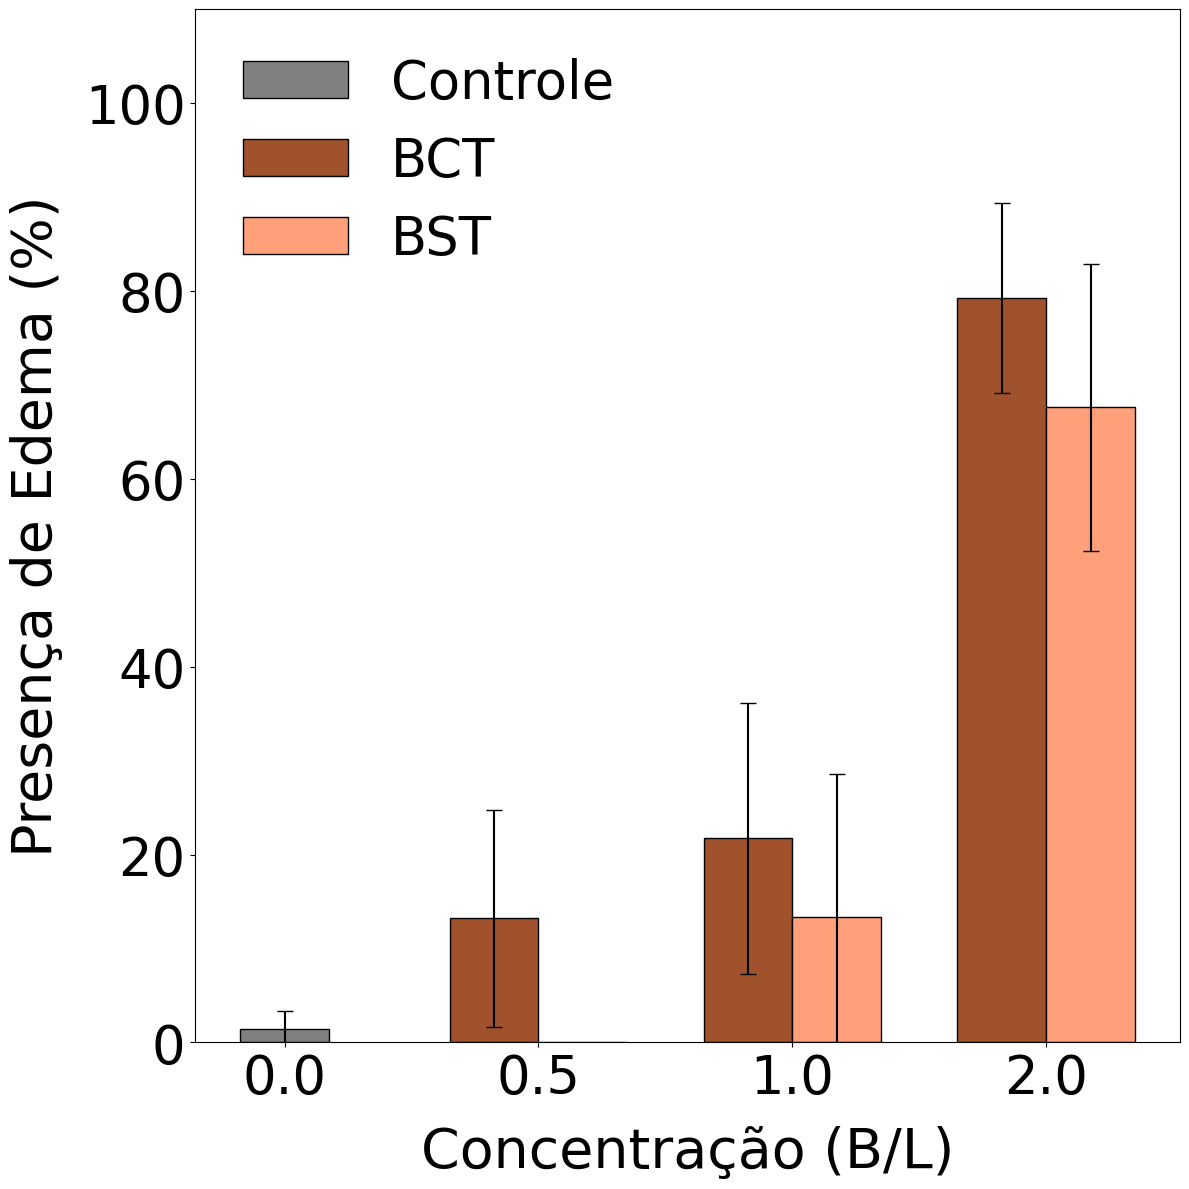

In [410]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. Carregar dados
# -------------------------------------------------------------------------
df = pd.read_csv("edemas.csv", sep=";", encoding="latin1")

# Converter colunas binárias Yes/No → 1/0
cols_binarias = ['Edema', 'Deformação', 'Bexiga']
df[cols_binarias] = df[cols_binarias].replace({'Yes': 1, 'No': 0})

# -------------------------------------------------------------------------
# 2. Porcentagem de Edema por Data dentro de cada grupo
# -------------------------------------------------------------------------
df_por_data = (
    df.groupby(['Tratamento', 'Concentração', 'Data'])['Edema']
      .apply(lambda x: (x.sum() / len(x)) * 100)
      .reset_index(name='percent_edema')
)

# -------------------------------------------------------------------------
# 3. Média e desvio padrão das porcentagens entre datas
# -------------------------------------------------------------------------
df_stats = (
    df_por_data.groupby(['Tratamento', 'Concentração'])['percent_edema']
      .agg(['mean', 'std'])
      .reset_index()
)

# -------------------------------------------------------------------------
# 4. Preparação para o gráfico
# -------------------------------------------------------------------------
controle = df_stats[df_stats['Tratamento'] == 'Controle']
trat = df_stats[df_stats['Tratamento'] != 'Controle']

concentracoes = sorted(trat['Concentração'].unique())

bar_width = 0.35
x = np.arange(len(concentracoes)) + 1

# Definir cores fixas
colors = {
    'Controle': 'gray',
    'BCT': 'sienna',
    'BST': 'lightsalmon'
}

fig, ax = plt.subplots(figsize=(12, 12))

# -------------------------------------------------------------------------
# 5. Barra do Controle (concentração 0.0)
# -------------------------------------------------------------------------
if not controle.empty:
    c_mean = controle['mean'].values[0]
    c_sd   = controle['std'].values[0]

    ax.bar(
        0.0, c_mean, width=bar_width,
        color=colors['Controle'], edgecolor='black',
        label='Controle'
    )
    ax.errorbar(0.0, c_mean, yerr=c_sd, fmt='none', ecolor='black', capsize=6)

# -------------------------------------------------------------------------
# 6. Barras BCT / BST para cada concentração
# -------------------------------------------------------------------------
for i, conc in enumerate(concentracoes, start=1):

    # BCT
    row_bct = df_stats[(df_stats['Tratamento'] == 'BCT') &
                       (df_stats['Concentração'] == conc)]

    if not row_bct.empty:
        ax.bar(
            i - bar_width/2, row_bct['mean'].values[0],
            width=bar_width, color=colors['BCT'], edgecolor='black',
            label='BCT'
        )
        ax.errorbar(
            i - bar_width/2, row_bct['mean'], yerr=row_bct['std'],
            fmt='none', ecolor='black', capsize=6
        )

    # BST
    row_bst = df_stats[(df_stats['Tratamento'] == 'BST') &
                       (df_stats['Concentração'] == conc)]

    if not row_bst.empty:
        ax.bar(
            i + bar_width/2, row_bst['mean'].values[0],
            width=bar_width, color=colors['BST'], edgecolor='black',
            label='BST'
        )
        ax.errorbar(
            i + bar_width/2, row_bst['mean'], yerr=row_bst['std'],
            fmt='none', ecolor='black', capsize=6
        )

# -------------------------------------------------------------------------
# 7. Ajustes do gráfico
# -------------------------------------------------------------------------
ax.set_xlabel('Concentração (B/L)', fontsize=40, labelpad=15)
ax.set_ylabel('Presença de Edema (%)', fontsize=40, labelpad=15)
# Garantir que concentrações virem números de verdade
trat['Concentração'] = trat['Concentração'].str.replace(',', '.', regex=False).astype(float)

concentracoes = sorted(trat['Concentração'].unique())


ax.set_xticks([0.0] + list(np.arange(1, len(concentracoes)+1)))
ax.set_xticklabels(['0.0'] + [f"{c:.1f}" for c in concentracoes], fontsize=38)


ax.set_ylim(0, 110)
ax.tick_params(axis='y', labelsize=38)

# Legenda sem repetição
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
leg = ax.legend(by_label.values(), by_label.keys(), fontsize=38)
leg.get_frame().set_facecolor('none')
leg.get_frame().set_edgecolor('none')

plt.tight_layout()
df_stats_edema = df_stats
plt.show()


## Kruskal Wallis para distribuições não normais

C:\Users\andre23035\AppData\Local\Temp\ipykernel_28424\2452775687.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols_binarias] = df[cols_binarias].replace({'Yes': 1, 'No': 0})
C:\Users\andre23035\AppData\Local\Temp\ipykernel_28424\2452775687.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trat['Concentração'] = trat['Concentração'].astype(str).str.replace(',', '.', regex=False).astype(float)
C:\Users\andre23035\AppData\Local\Temp\ipykernel_28424\2452775687.py:40: SettingWithCopyWarning: 
A value is tryin

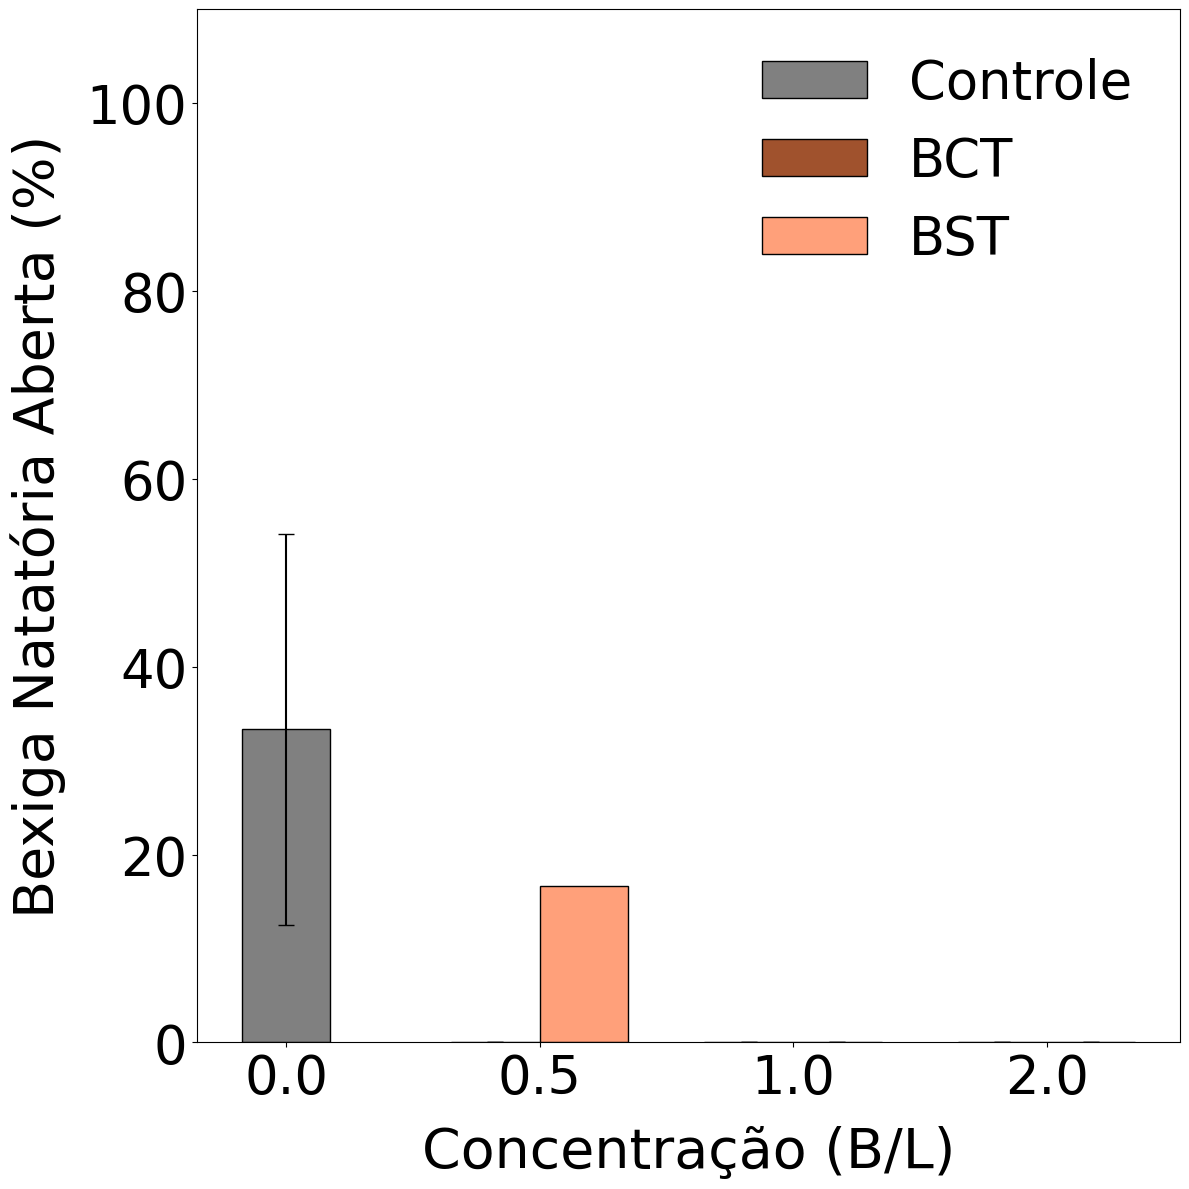

In [411]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. Carregar e preparar dados
# -------------------------------------------------------------------------
df = pd.read_csv("edemas.csv", sep=";", encoding="latin1")

# Converter colunas binárias Yes/No → 1/0
cols_binarias = ['Edema', 'Deformação', 'Bexiga']
df[cols_binarias] = df[cols_binarias].replace({'Yes': 1, 'No': 0})

# -------------------------------------------------------------------------
# 2. Porcentagem por Data para Bexiga
# -------------------------------------------------------------------------
df_por_data = (
    df.groupby(['Tratamento', 'Concentração', 'Data'])['Bexiga']
      .apply(lambda x: (x.sum() / len(x)) * 100)
      .reset_index(name='percent_bexiga')
)

# -------------------------------------------------------------------------
# 3. Média e desvio padrão entre datas
# -------------------------------------------------------------------------
df_stats = (
    df_por_data.groupby(['Tratamento', 'Concentração'])['percent_bexiga']
      .agg(['mean', 'std'])
      .reset_index()
)

# -------------------------------------------------------------------------
# 4. Preparação do gráfico
# -------------------------------------------------------------------------
controle = df_stats[df_stats['Tratamento'] == 'Controle']
trat = df_stats[df_stats['Tratamento'] != 'Controle']

# corrigir vírgula -> ponto e transformar em float
trat['Concentração'] = trat['Concentração'].astype(str).str.replace(',', '.', regex=False).astype(float)
controle['Concentração'] = controle['Concentração'].astype(str).str.replace(',', '.', regex=False).astype(float)

concentracoes = sorted(trat['Concentração'].unique())

bar_width = 0.35

colors = {
    'Controle': 'gray',
    'BCT': 'sienna',
    'BST': 'lightsalmon'
}

fig, ax = plt.subplots(figsize=(12, 12))

# -------------------------------------------------------------------------
# 5. Barra do controle
# -------------------------------------------------------------------------
if not controle.empty:
    c_mean = controle['mean'].values[0]
    c_sd   = controle['std'].values[0]

    ax.bar(
        0.0, c_mean,
        width=bar_width, color=colors['Controle'], edgecolor='black',
        label='Controle'
    )
    ax.errorbar(0.0, c_mean, yerr=c_sd, fmt='none', ecolor='black', capsize=6)

# -------------------------------------------------------------------------
# 6. Barras BCT / BST
# -------------------------------------------------------------------------
for i, conc in enumerate(concentracoes, start=1):

    # BCT
    row_bct = df_stats[(df_stats['Tratamento'] == 'BCT') &
                       (df_stats['Concentração'].astype(str).str.replace(',', '.', regex=False).astype(float) == conc)]

    if not row_bct.empty:
        ax.bar(
            i - bar_width/2, row_bct['mean'].values[0],
            width=bar_width, color=colors['BCT'], edgecolor='black',
            label='BCT'
        )
        ax.errorbar(
            i - bar_width/2, row_bct['mean'], yerr=row_bct['std'],
            fmt='none', ecolor='black', capsize=6
        )

    # BST
    row_bst = df_stats[(df_stats['Tratamento'] == 'BST') &
                       (df_stats['Concentração'].astype(str).str.replace(',', '.', regex=False).astype(float) == conc)]

    if not row_bst.empty:
        ax.bar(
            i + bar_width/2, row_bst['mean'].values[0],
            width=bar_width, color=colors['BST'], edgecolor='black',
            label='BST'
        )
        ax.errorbar(
            i + bar_width/2, row_bst['mean'], yerr=row_bst['std'],
            fmt='none', ecolor='black', capsize=6
        )

# -------------------------------------------------------------------------
# 7. Eixos e rótulos
# -------------------------------------------------------------------------
ax.set_xlabel('Concentração (B/L)', fontsize=40, labelpad=15)
ax.set_ylabel('Bexiga Natatória Aberta (%)', fontsize=40, labelpad=15)

ax.set_xticks([0.0] + list(np.arange(1, len(concentracoes)+1)))
ax.set_xticklabels(['0.0'] + [f"{c:.1f}" for c in concentracoes], fontsize=38)

ax.set_ylim(0, 110)
ax.tick_params(axis='y', labelsize=38)

# Legenda única
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
leg = ax.legend(by_label.values(), by_label.keys(), fontsize=38)
leg.get_frame().set_facecolor('none')
leg.get_frame().set_edgecolor('none')

plt.tight_layout()
df_stats_bexiga = df_stats
plt.show()


C:\Users\andre23035\AppData\Local\Temp\ipykernel_28424\503066745.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols_binarias] = df[cols_binarias].replace({'Yes': 1, 'No': 0})
C:\Users\andre23035\AppData\Local\Temp\ipykernel_28424\503066745.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trat['Concentração'] = trat['Concentração'].astype(str).str.replace(',', '.', regex=False).astype(float)
C:\Users\andre23035\AppData\Local\Temp\ipykernel_28424\503066745.py:40: SettingWithCopyWarning: 
A value is trying t

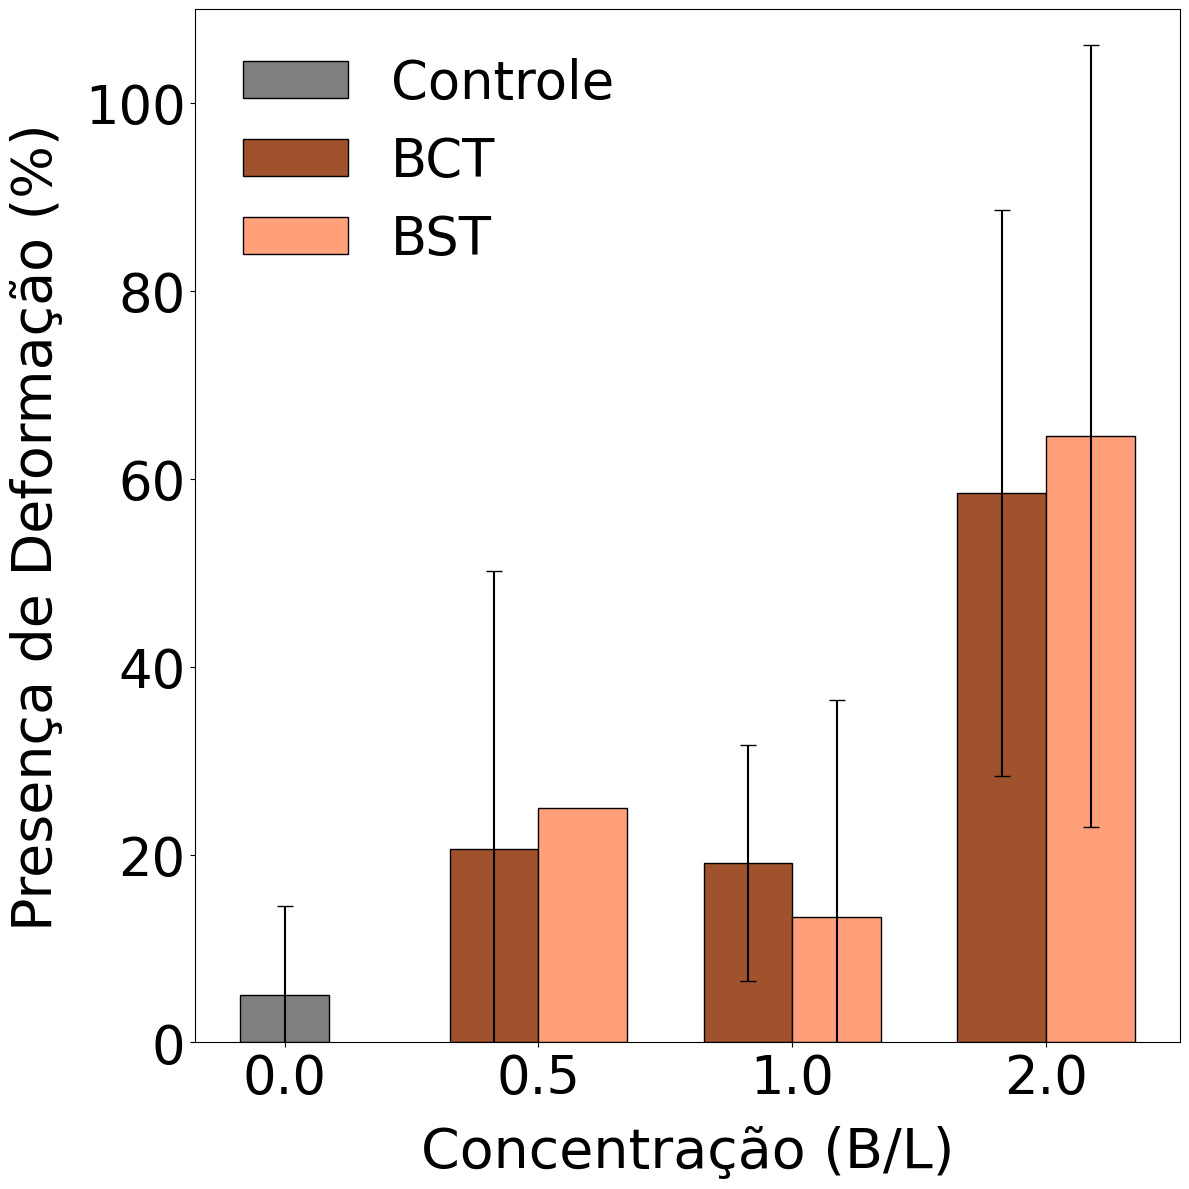

In [419]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. Carregar e preparar dados
# -------------------------------------------------------------------------
df = pd.read_csv("edemas.csv", sep=";", encoding="latin1")

# Converter colunas binárias Yes/No → 1/0
cols_binarias = ['Edema', 'Deformação', 'Bexiga']
df[cols_binarias] = df[cols_binarias].replace({'Yes': 1, 'No': 0})

# -------------------------------------------------------------------------
# 2. Porcentagem por Data para Deformação
# -------------------------------------------------------------------------
df_por_data = (
    df.groupby(['Tratamento', 'Concentração', 'Data'])['Deformação']
      .apply(lambda x: (x.sum() / len(x)) * 100)
      .reset_index(name='percent_deformacao')
)

# -------------------------------------------------------------------------
# 3. Média e desvio padrão entre datas
# -------------------------------------------------------------------------
df_stats = (
    df_por_data.groupby(['Tratamento', 'Concentração'])['percent_deformacao']
      .agg(['mean', 'std'])
      .reset_index()
)

# -------------------------------------------------------------------------
# 4. Preparação do gráfico
# -------------------------------------------------------------------------
controle = df_stats[df_stats['Tratamento'] == 'Controle']
trat = df_stats[df_stats['Tratamento'] != 'Controle']

# corrigir vírgula -> ponto e transformar em float
trat['Concentração'] = trat['Concentração'].astype(str).str.replace(',', '.', regex=False).astype(float)
controle['Concentração'] = controle['Concentração'].astype(str).str.replace(',', '.', regex=False).astype(float)

concentracoes = sorted(trat['Concentração'].unique())

bar_width = 0.35

colors = {
    'Controle': 'gray',
    'BCT': 'sienna',
    'BST': 'lightsalmon'
}

fig, ax = plt.subplots(figsize=(12, 12))

# -------------------------------------------------------------------------
# 5. Barra do controle
# -------------------------------------------------------------------------
if not controle.empty:
    c_mean = controle['mean'].values[0]
    c_sd   = controle['std'].values[0]

    ax.bar(
        0.0, c_mean,
        width=bar_width, color=colors['Controle'], edgecolor='black',
        label='Controle'
    )
    ax.errorbar(0.0, c_mean, yerr=c_sd, fmt='none', ecolor='black', capsize=6)

# -------------------------------------------------------------------------
# 6. Barras BCT / BST
# -------------------------------------------------------------------------
for i, conc in enumerate(concentracoes, start=1):

    # BCT
    row_bct = df_stats[
        (df_stats['Tratamento'] == 'BCT') &
        (df_stats['Concentração'].astype(str).str.replace(',', '.', regex=False).astype(float) == conc)
    ]

    if not row_bct.empty:
        ax.bar(
            i - bar_width/2, row_bct['mean'].values[0],
            width=bar_width, color=colors['BCT'], edgecolor='black',
            label='BCT'
        )
        ax.errorbar(
            i - bar_width/2, row_bct['mean'], yerr=row_bct['std'],
            fmt='none', ecolor='black', capsize=6
        )

    # BST
    row_bst = df_stats[
        (df_stats['Tratamento'] == 'BST') &
        (df_stats['Concentração'].astype(str).str.replace(',', '.', regex=False).astype(float) == conc)
    ]

    if not row_bst.empty:
        ax.bar(
            i + bar_width/2, row_bst['mean'].values[0],
            width=bar_width, color=colors['BST'], edgecolor='black',
            label='BST'
        )
        ax.errorbar(
            i + bar_width/2, row_bst['mean'], yerr=row_bst['std'],
            fmt='none', ecolor='black', capsize=6

        )



# -------------------------------------------------------------------------
# 7. Eixos e rótulos
# -------------------------------------------------------------------------
ax.set_xlabel('Concentração (B/L)', fontsize=40, labelpad=15)
ax.set_ylabel('Presença de Deformação (%)', fontsize=40, labelpad=15)

ax.set_xticks([0.0] + list(np.arange(1, len(concentracoes)+1)))
ax.set_xticklabels(['0.0'] + [f"{c:.1f}" for c in concentracoes], fontsize=38)

ax.set_ylim(0, 110)
ax.tick_params(axis='y', labelsize=38)

# Legenda única
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
leg = ax.legend(by_label.values(), by_label.keys(), fontsize=38)
leg.get_frame().set_facecolor('none')
leg.get_frame().set_edgecolor('none')

plt.tight_layout()
df_stats_deformacao = df_stats
plt.show()
